# **Home Credit Default Risk**

## Motivación y contexto del trabajo

En este documento estaremos trabajando con el dataset **Home Credit Default Risk** cuya información se puede encontrar [aquí](https://www.kaggle.com/competitions/home-credit-default-risk/overview). A rasgos generales tenemos un dataset en el que tenemos que precedir si los clientes nos devolverán el prestamo o no según los datos que tenemos. Mientras que el dataset original tiene varios archivos .csv con información, nosotros nos limitaremos a tomar el archivo **application_train.csv**

La motivación tras el uso de este dataset se debe a que es un problema de aprendizaje automático totalmente aplicable al mundo real.

## Prepocesamiento de datos

### Importanción del librerias
Importamos las librerias que vamos a usar, como vamos a usar la libreria `optuna` para optimización de hiperparámetros la instalamos.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.feature_selection import VarianceThreshold, f_classif
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve
import lightgbm as lgb
import optuna
from sklearn.preprocessing import OrdinalEncoder
from sklearn.inspection import permutation_importance

### Carga y exploración de datos

Vamos a leer los archivos y ver que dimensiones tenemos y cuál es el balance de clases

In [ ]:
# Configuración visual para que los gráficos luzcan profesionales
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None) # Para poder ver todas las columnas

# Cargamos el archivo principal de entrenamiento
df = pd.read_csv('application_train.csv')

# ==============================================================================
# PRIMERA EXPLORACIÓN
# ==============================================================================
print(f"Dimensiones del dataset: {df.shape[0]} registros y {df.shape[1]} variables.")
print("\nDistribución de la variable objetivo (0 = Paga, 1 = Impaga):")
print(df['TARGET'].value_counts(normalize=True) * 100)

# Mostramos las primeras 5 filas
df.head()

Dimensiones del dataset: 307511 registros y 122 variables.

Distribución de la variable objetivo (0 = Paga, 1 = Impaga):
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Vemos que los datos están super desbalanceados además de que tenemos 122 variables, por lo que tendremos que reducir su número de alguna forma. Vamos a ver la distribución de los valores faltantes

### Tratamiento de NA's (eliminación)

In [ ]:
# ==============================================================================
# ANÁLISIS DE VALORES FALTANTES (Nulos)
# ==============================================================================
# Calculamos el total de nulos por columna
total_nulos = df.isnull().sum()

# Calculamos el porcentaje que representan sobre el total de filas
porcentaje_nulos = (total_nulos / len(df)) * 100

# Juntamos ambas métricas en un DataFrame para visualizarlo bien
tabla_nulos = pd.concat([total_nulos, porcentaje_nulos], axis=1, keys=['Total Nulos', 'Porcentaje (%)'])

# Filtramos para quedarnos solo con las columnas que tienen nulos
# y las ordenamos de mayor a menor porcentaje
tabla_nulos = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

print(f"De las {df.shape[1]} columnas del dataset, {len(tabla_nulos)} tienen valores faltantes.\n")

# Mostramos el "Top 20" de columnas más problemáticas
tabla_nulos.head(20)

De las 122 columnas del dataset, 67 tienen valores faltantes.



,Total Nulos,Porcentaje (%)
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


Vemos que hay muchas variables que tienen valores faltantes. Vamos a tomar una decisión que si bien puede considerarse "drástica" creemos que está más que justificada.

Vamos a **eliminar las variables que tengan más de un 45% de NA**, esto nos ayudará a recortar el número de variables. Se establece así el umbral pues las variables que tengan más de un 45% de NA si imputaramos esos NA por valores, esa variable tendría más de la mitad de las instancias artificiales.

In [ ]:
# Creamos una variable que indique los NA de la instancia
df['NULOS_INICIALES'] = df.isnull().sum(axis=1)

In [ ]:
# ==============================================================================
#  ELIMINACIÓN DE COLUMNAS CON EXCESO DE NULOS
# ==============================================================================
# Definimos nuestro límite (45%)
umbral_nulos = 45.0

# Identificamos qué columnas superan el umbral usando la tabla que creamos antes
columnas_a_eliminar = tabla_nulos[tabla_nulos['Porcentaje (%)'] > umbral_nulos].index.tolist()

# Eliminamos esas columnas del DataFrame principal
df_limpio = df.drop(columns=columnas_a_eliminar)

print(f"Se han eliminado {len(columnas_a_eliminar)} columnas que superaban el {umbral_nulos}% de nulos.")
print(f"El dataset ha pasado de {df.shape[1]} a {df_limpio.shape[1]} columnas.")

Se han eliminado 49 columnas que superaban el 45.0% de nulos.
El dataset ha pasado de 123 a 74 columnas.


Vemos que ya hemos reducido severamente el número de variables

### Separación en varios conjuntos (*holdout* estratificado)

Antes de continuar, vamos a separar nuestros datos en tres conjuntos (entrenamiento, validación y test) de forma **estratificada**, pues las clases están desbalanceadas. Lo hacemos ya por metodología, para guardar los otros conjuntos y usar solo el de entrenamiento por si tenemos que hacer alguna transformación en los datos usar solo los datos de entrenamiento y evitar **data leakage** (fuga de datos). Se opta por este método y se descarta la validación cruzada porque tenemos un amplio volumen de datos.

In [ ]:
# ==============================================================================
#  DIVISIÓN DE DATOS EN 3 VÍAS (Train, Validation, Test)
# ==============================================================================


# Separamos la variable objetivo (y) de las predictoras (X)
X = df_limpio.drop(columns=['TARGET'])
y = df_limpio['TARGET']

# Primera división: Separamos el Test definitivo (15%) y guardamos el resto para Desarrollo (85%)
X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Segunda división: El Desarrollo lo partimos en Train (70%) y Validación (30%)
X_train, X_val, y_train, y_val = train_test_split(
    X_desarrollo, y_desarrollo, test_size=0.3, random_state=42, stratify=y_desarrollo
)

print(f"Conjunto de Entrenamiento (Train): {X_train.shape[0]} filas")
print(f"Conjunto de Validación (Val): {X_val.shape[0]} filas")
print(f"Conjunto de Prueba (Test): {X_test.shape[0]} filas\n")

Conjunto de Entrenamiento (Train): 182968 filas
Conjunto de Validación (Val): 78416 filas
Conjunto de Prueba (Test): 46127 filas



### Limpieza de caracterísitcas y tratamiento de NA (imputación)

Antes de imputar los NA sobre las columnas numéricas vamos a eliminar aquellas que estén muy correladas entre sí:

De 61 columnas con formato numérico, solo 26 son realmente continuas.



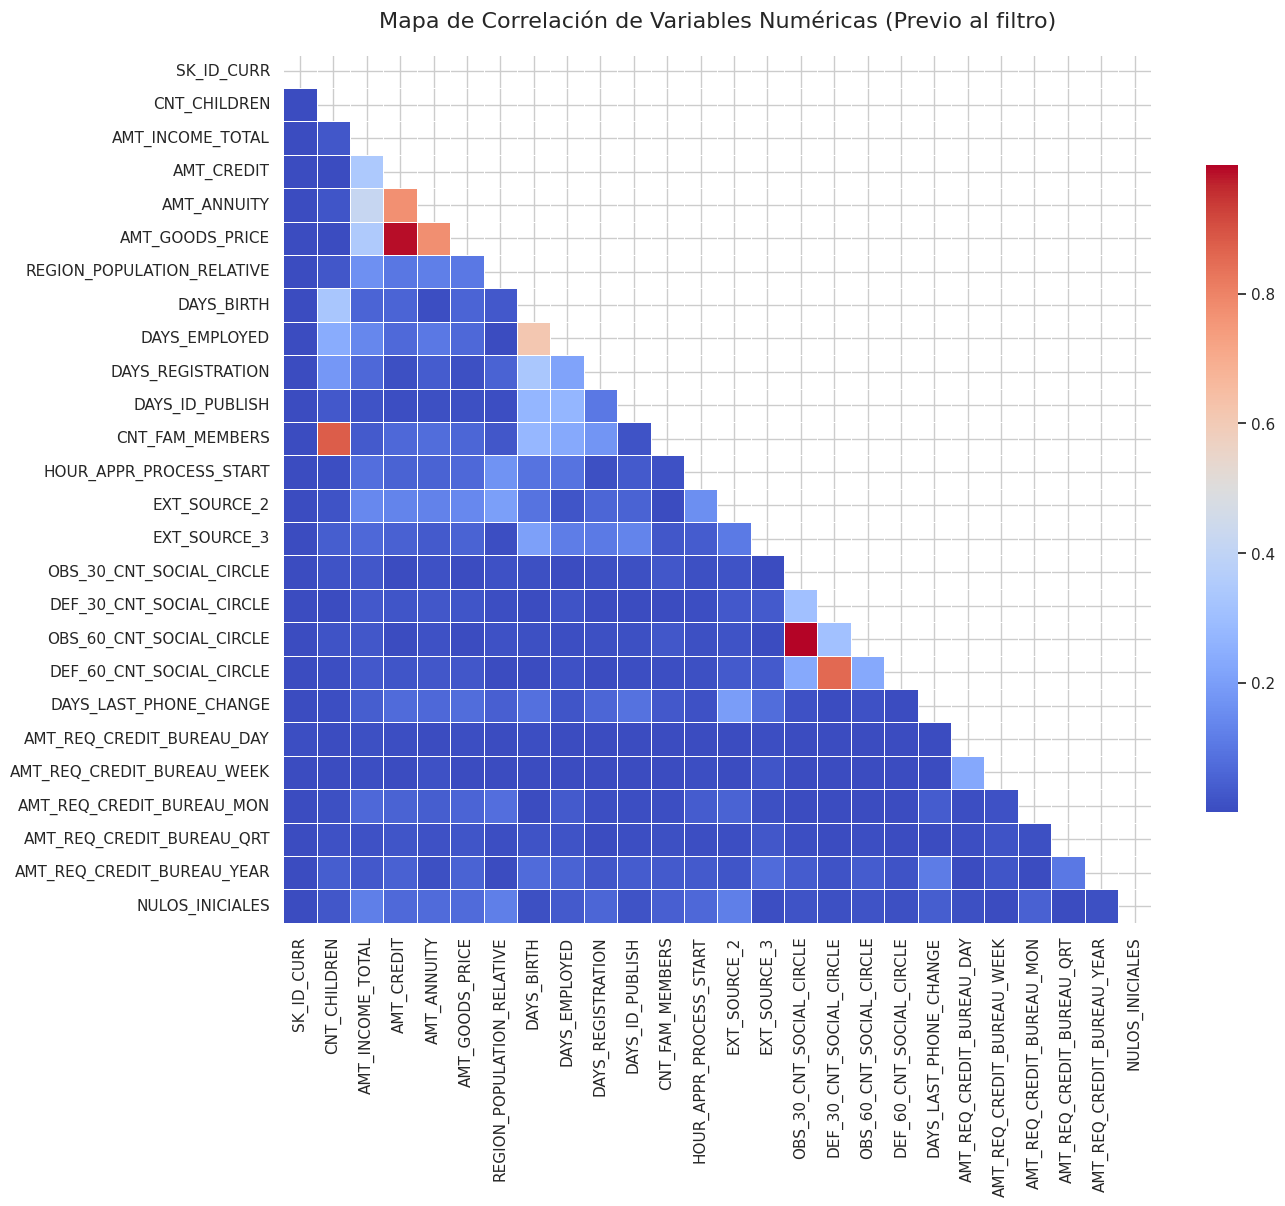

Se han detectado 4 columnas continuas con una correlación mayor al 85.0%.

Columnas a eliminar: ['AMT_GOODS_PRICE', 'CNT_FAM_MEMBERS', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']

Dimensiones finales tras eliminar correlacionadas:
X_train: (182968, 69)
X_val:   (78416, 69)
X_test:  (46127, 69)


In [ ]:
# ==============================================================================
# ELIMINACIÓN DE VARIABLES CONTINUAS ALTAMENTE CORRELACIONADAS
# ==============================================================================

# Seleccionamos las columnas que tienen formato numérico
posibles_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

# Filtramos para quedarnos solo con las "verdaderas" continuas.
# Consideramos continua a una variable si tiene más de 5 valores únicos.
# (Esto excluye automáticamente las binarias y categóricas codificadas numéricamente).
verdaderas_numericas = [columna for columna in posibles_numericas if X_train[columna].nunique() > 5]

print(f"De {len(posibles_numericas)} columnas con formato numérico, solo {len(verdaderas_numericas)} son realmente continuas.\n")

# Calculamos la matriz de correlación (en valor absoluto)
matriz_corr = X_train[verdaderas_numericas].corr().abs()

# --- INICIO DEL GRÁFICO  ---
plt.figure(figsize=(14, 12))
# Creamos una máscara para ocultar el triángulo superior
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Generamos el mapa de calor sin números (annot=False) y colores divergentes (coolwarm)
sns.heatmap(matriz_corr, mask=mask, cmap="coolwarm", annot=False,
            square=True, linewidths=.5, cbar_kws={"shrink": .7})
plt.title("Mapa de Correlación de Variables Numéricas (Previo al filtro)", fontsize=16, pad=20)
plt.show()

# Nos quedamos solo con el triángulo superior de la matriz
triangulo_superior = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))

# Definimos el umbral (0.85)
umbral_correlacion = 0.85

# Buscamos qué columnas superan el umbral
columnas_correlacionadas = [columna for columna in triangulo_superior.columns if any(triangulo_superior[columna] > umbral_correlacion)]

print(f"Se han detectado {len(columnas_correlacionadas)} columnas continuas con una correlación mayor al {umbral_correlacion*100}%.\n")
print(f"Columnas a eliminar: {columnas_correlacionadas}\n")

# Eliminamos estas variables redundantes en TODOS los conjuntos
X_train = X_train.drop(columns=columnas_correlacionadas)
X_val = X_val.drop(columns=columnas_correlacionadas)
X_test = X_test.drop(columns=columnas_correlacionadas)

print("Dimensiones finales tras eliminar correlacionadas:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Vamos a ver un resumen de las columnas

In [ ]:
resumen_cols = pd.DataFrame({
    'dtype': X_train.dtypes,
    'n_unicos': X_train.nunique(dropna=True),
    'n_nulos': X_train.isna().sum(),
    '%_unicos': (X_train.nunique(dropna=True) / len(X_train) * 100).round(2),
    '%_nulos': X_train.isna().sum() / len(X_train) * 100
})

# Añadir ejemplos de valores
resumen_cols['ejemplos'] = [
    X_train[col].dropna().unique()[:10].tolist()
    for col in X_train.columns
]

resumen_cols = resumen_cols.sort_values('n_unicos')
pd.set_option('display.max_colwidth', None)
resumen_cols

,dtype,n_unicos,n_nulos,%_unicos,%_nulos,ejemplos
FLAG_DOCUMENT_12,int64,1,0,0.00,0.000000,[0]
NAME_CONTRACT_TYPE,object,2,0,0.00,0.000000,"[Revolving loans, Cash loans]"
FLAG_OWN_REALTY,object,2,0,0.00,0.000000,"[Y, N]"
FLAG_OWN_CAR,object,2,0,0.00,0.000000,"[N, Y]"
FLAG_EMP_PHONE,int64,2,0,0.00,0.000000,"[1, 0]"
...,...,...,...,...,...,...
AMT_ANNUITY,float64,12401,8,6.78,0.004372,"[9000.0, 45549.0, 39730.5, 34236.0, 52366.5, 34483.5, 13963.5, 28300.5, 93127.5, 34209.0]"
DAYS_REGISTRATION,float64,14992,0,8.19,0.000000,"[-4347.0, -89.0, -6902.0, -8085.0, -8492.0, -7485.0, -3323.0, -9047.0, -962.0, -4686.0]"
DAYS_BIRTH,int64,17352,0,9.48,0.000000,"[-9576, -20568, -18370, -16993, -16110, -13358, -8066, -16146, -18309, -10218]"
EXT_SOURCE_2,float64,94140,375,51.45,0.204954,"[0.4694036763777429, 0.1273735515645627, 0.6967414176908736, 0.5406023857078662, 0.7725288491495007, 0.7462711526848883, 0.5938363067914445, 0.0346801410082532, 0.3731377909248553, 0.4724765804646744]"


Vemos que hay una columna que tiene un valor único, la eliminaremos posteriormente cuando hagamos selección de variables.

Ahora identificamos las variables categóricas y numéricas para imputar las numéricas con la moda y las categóricas creando una nueva categoría. Nos quedamos con la espinita de no hacer imputación predictiva, pero debido a la cantidad de datos y a la cantidad de valores faltantes sería inviable este proceso. Además tenemos más de un valor faltante en cada dato, por lo que habría casos en los que no dispondríamos siquiera de las variables predictoras necesarias para imputar correctamente un registro.

In [ ]:
# ==============================================================================
# CREACIÓN DE LA VARIABLE "CANTIDAD_NULOS"
# ==============================================================================

X_train['CANTIDAD_NULOS'] = X_train.isnull().sum(axis=1)
X_val['CANTIDAD_NULOS'] = X_val.isnull().sum(axis=1)
X_test['CANTIDAD_NULOS'] = X_test.isnull().sum(axis=1)

print("Variable 'CANTIDAD_NULOS' creada con éxito.\n")

# ==============================================================================
# IDENTIFICACIÓN DE TIPOS DE VARIABLES
# ==============================================================================

# Variables numéricas continuas (>5 valores distintos)
cols_numericas_continuas = [
    col for col in X_train.columns
    if (
        pd.api.types.is_numeric_dtype(X_train[col])
        and X_train[col].nunique(dropna=True) > 5
    )
]

# Variables numéricas discretas/binarias (<=5 valores distintos)
cols_numericas_discretas = [
    col for col in X_train.columns
    if (
        pd.api.types.is_numeric_dtype(X_train[col])
        and col not in cols_numericas_continuas
    )
]

# Variables categóricas de texto
cols_categoricas = [
    col for col in X_train.columns
    if not pd.api.types.is_numeric_dtype(X_train[col])
]

print(f"Numéricas continuas: {len(cols_numericas_continuas)}")
print(f"Numéricas discretas/binarias: {len(cols_numericas_discretas)}")
print(f"Categóricas texto: {len(cols_categoricas)}\n")

# ==============================================================================
# IMPUTACIÓN DE NULOS
# ==============================================================================

# Continuas -> mediana
imp_num = SimpleImputer(strategy='median')

# Binarias/discretas -> categoría especial -1
imp_disc = SimpleImputer(strategy='constant', fill_value=-1)

# Texto -> categoría especial "Desconocido"
imp_cat = SimpleImputer(strategy='constant', fill_value='Desconocido')

# ---------------- TRAIN ----------------

X_train[cols_numericas_continuas] = imp_num.fit_transform(
    X_train[cols_numericas_continuas]
)

X_train[cols_numericas_discretas] = imp_disc.fit_transform(
    X_train[cols_numericas_discretas]
)

X_train[cols_categoricas] = imp_cat.fit_transform(
    X_train[cols_categoricas]
)

# ---------------- VALIDACIÓN ----------------

X_val[cols_numericas_continuas] = imp_num.transform(
    X_val[cols_numericas_continuas]
)

X_val[cols_numericas_discretas] = imp_disc.transform(
    X_val[cols_numericas_discretas]
)

X_val[cols_categoricas] = imp_cat.transform(
    X_val[cols_categoricas]
)

# ---------------- TEST ----------------

X_test[cols_numericas_continuas] = imp_num.transform(
    X_test[cols_numericas_continuas]
)

X_test[cols_numericas_discretas] = imp_disc.transform(
    X_test[cols_numericas_discretas]
)

X_test[cols_categoricas] = imp_cat.transform(
    X_test[cols_categoricas]
)

print("Valores nulos imputados correctamente.\n")

# ==============================================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ==============================================================================

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[cols_categoricas] = encoder.fit_transform(
    X_train[cols_categoricas]
)

X_val[cols_categoricas] = encoder.transform(
    X_val[cols_categoricas]
)

X_test[cols_categoricas] = encoder.transform(
    X_test[cols_categoricas]
)

print("Variables categóricas codificadas correctamente.\n")

# ==============================================================================
# COMPROBACIÓN FINAL
# ==============================================================================

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Nulos restantes train: {X_train.isnull().sum().sum()}")
print(f"Nulos restantes val:   {X_val.isnull().sum().sum()}")
print(f"Nulos restantes test:  {X_test.isnull().sum().sum()}")

Variable 'CANTIDAD_NULOS' creada con éxito.

Numéricas continuas: 23
Numéricas discretas/binarias: 35
Categóricas texto: 12

Valores nulos imputados correctamente.

Variables categóricas codificadas correctamente.

X_train: (182968, 70)
X_val:   (78416, 70)
X_test:  (46127, 70)
Nulos restantes train: 0
Nulos restantes val:   0
Nulos restantes test:  0


### Selección de características

Como ya hemos rellenado los valores faltantes, ahora es lo que vamos a hacer es un poco de ingeniería de características para **reducir el número de las mismas**.

Para ello vamos a buscar características "irrelevantes" para nuestra tarea que podamos omitir.

Lo vamos a hacer antes de usar modelos, por lo que **descartamos métodos de envoltura**, nos quedaremos con los métodos de limpieza básicos (no supervisados) como la eliminación de variables muy correladas y **métodos de filtrado** que usan test estadísticos para ver que variables son irrelevantes (como el test ANOVA o el test chi cuadrado, de las librerias `scipy` la función `chi2_contingency` y en módulo `feature_selection` de la libreria `scikit-learn` la función  `f_classif`).

In [ ]:
umbral_p_valor = 0.1

# ==============================================================================
# FILTROS SUPERVISADOS (p-valor < umbral_p_valor)
# ==============================================================================

print(f"REPORTE DE TESTS ESTADÍSTICOS (Umbral p-valor < {umbral_p_valor})")

# ==============================================================================
# A. ANOVA PARA VARIABLES NUMÉRICAS CONTINUAS
# ==============================================================================

F_stats, p_values_anova = f_classif(
    X_train[cols_numericas_continuas],
    y_train
)

num_cont_final = []
num_cont_eliminadas = []

for col, p_val in zip(cols_numericas_continuas, p_values_anova):

    if p_val < umbral_p_valor:
        num_cont_final.append(col)
    else:
        num_cont_eliminadas.append((col, p_val))

print("\n--- Resultados ANOVA (Numéricas Continuas) ---")

if len(num_cont_eliminadas) > 0:

    for col, p_val in sorted(
        num_cont_eliminadas,
        key=lambda x: x[1],
        reverse=True
    ):
        print(
            f"  Se elimina '{col}' "
            f"-> p-valor: {p_val:.6f}"
        )

else:
    print("  Todas las continuas pasaron ANOVA.")

print(
    f"Resumen Continuas: "
    f"{len(cols_numericas_continuas)} -> {len(num_cont_final)}"
)

# ==============================================================================
# B. CHI² PARA VARIABLES NUMÉRICAS DISCRETAS / BINARIAS
# ==============================================================================

num_disc_final = []
num_disc_eliminadas = []

for col in cols_numericas_discretas:

    tabla = pd.crosstab(
        X_train[col],
        y_train
    )

    chi2_stat, p_val, dof, expected = chi2_contingency(tabla)

    if p_val < umbral_p_valor:
        num_disc_final.append(col)
    else:
        num_disc_eliminadas.append((col, p_val))

print("\n--- Resultados Chi² (Numéricas Discretas/Binarias) ---")

if len(num_disc_eliminadas) > 0:

    for col, p_val in sorted(
        num_disc_eliminadas,
        key=lambda x: x[1],
        reverse=True
    ):
        print(
            f"  Se elimina '{col}' "
            f"-> p-valor: {p_val:.6f}"
        )

else:
    print("  Todas las discretas pasaron Chi².")

print(
    f"Resumen Discretas: "
    f"{len(cols_numericas_discretas)} -> {len(num_disc_final)}"
)

# ==============================================================================
# C. CHI² PARA VARIABLES CATEGÓRICAS
# ==============================================================================

cat_final = []
cat_eliminadas = []

for col in cols_categoricas:

    tabla = pd.crosstab(
        X_train[col],
        y_train
    )

    chi2_stat, p_val, dof, expected = chi2_contingency(tabla)

    if p_val < umbral_p_valor:
        cat_final.append(col)
    else:
        cat_eliminadas.append((col, p_val))

print("\n--- Resultados Chi² (Categóricas) ---")

if len(cat_eliminadas) > 0:

    for col, p_val in sorted(
        cat_eliminadas,
        key=lambda x: x[1],
        reverse=True
    ):
        print(
            f"  Se elimina '{col}' "
            f"-> p-valor: {p_val:.6f}"
        )

else:
    print("  Todas las categóricas pasaron Chi².")

print(
    f"Resumen Categóricas: "
    f"{len(cols_categoricas)} -> {len(cat_final)}"
)

# ==============================================================================
# VARIABLES FINALES
# ==============================================================================

variables_finales = (
    num_cont_final +
    num_disc_final +
    cat_final
)

print("\n===================================")
print("RESUMEN GLOBAL")
print("===================================")

print(f"Variables iniciales: {X_train.shape[1]}")
print(f"Variables finales:   {len(variables_finales)}")
print(f"Variables eliminadas: {X_train.shape[1] - len(variables_finales)}")

# Aplicamos el filtro a todos los conjuntos

X_train = X_train[variables_finales]
X_val = X_val[variables_finales]
X_test = X_test[variables_finales]

print("\nDimensiones finales:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

REPORTE DE TESTS ESTADÍSTICOS (Umbral p-valor < 0.1)

--- Resultados ANOVA (Numéricas Continuas) ---
  Se elimina 'AMT_REQ_CREDIT_BUREAU_WEEK' -> p-valor: 0.974627
  Se elimina 'SK_ID_CURR' -> p-valor: 0.444069
  Se elimina 'AMT_REQ_CREDIT_BUREAU_DAY' -> p-valor: 0.402892
Resumen Continuas: 23 -> 20

--- Resultados Chi² (Numéricas Discretas/Binarias) ---
  Se elimina 'FLAG_MOBIL' -> p-valor: 1.000000
  Se elimina 'FLAG_DOCUMENT_10' -> p-valor: 1.000000
  Se elimina 'FLAG_DOCUMENT_12' -> p-valor: 1.000000
  Se elimina 'FLAG_DOCUMENT_5' -> p-valor: 0.854075
  Se elimina 'LIVE_REGION_NOT_WORK_REGION' -> p-valor: 0.845963
  Se elimina 'FLAG_EMAIL' -> p-valor: 0.788368
  Se elimina 'FLAG_DOCUMENT_20' -> p-valor: 0.729980
  Se elimina 'FLAG_DOCUMENT_21' -> p-valor: 0.662202
  Se elimina 'REG_REGION_NOT_LIVE_REGION' -> p-valor: 0.609275
  Se elimina 'FLAG_DOCUMENT_7' -> p-valor: 0.597798
  Se elimina 'FLAG_CONT_MOBILE' -> p-valor: 0.574736
  Se elimina 'FLAG_DOCUMENT_19' -> p-valor: 0.541303


Ahora hacemos lo mismo para el criterio de Information Value

In [ ]:
# ==============================================================================
# CÁLCULO DE INFORMATION VALUE (IV) Y SELECCIÓN DE VARIABLES
# ==============================================================================

def calcular_iv(df, variable, target):
    """
    Calcula el Information Value (IV) de una variable respecto al target binario.
    Agrupa las variables continuas en deciles automáticamente.
    """
    # Si la variable tiene muchos valores únicos (continua), la dividimos en 10 cuantiles (deciles)
    if df[variable].nunique() > 10:
        # Usamos qcut para crear cubos del mismo tamaño, drop evita errores si hay valores repetidos masivamente
        binned = pd.qcut(df[variable], q=10, duplicates='drop')
        agrupado = df.groupby(binned, observed=False)
    else:
        # Si es discreta/categórica, agrupamos por sus valores únicos
        agrupado = df.groupby(variable)

    # Totales generales de la clase 0 (Good) y 1 (Bad)
    total_bad = df[target].sum()
    total_good = df[target].count() - total_bad

    iv_total = 0

    for nombre_grupo, grupo in agrupado:
        bad = grupo[target].sum()
        good = grupo.shape[0] - bad

        # Sumamos un valor epsilon minúsculo para evitar divisiones por cero o logaritmos de cero
        if bad == 0: bad = 0.0001
        if good == 0: good = 0.0001

        pct_bad = bad / total_bad
        pct_good = good / total_good

        # Cálculo del Weight of Evidence (WoE)
        woe = np.log(pct_good / pct_bad)

        # Sumamos al IV total de la variable
        iv_total += (pct_good - pct_bad) * woe

    return iv_total

# Unimos de nuevo X_train e y_train temporalmente para facilitar el cálculo
df_train_iv = X_train.copy()
df_train_iv['TARGET'] = y_train

resultados_iv = {}
variables_evaluar = X_train.columns.tolist()

# Calculamos el IV para cada variable
for col in variables_evaluar:
    try:
        iv_score = calcular_iv(df_train_iv, col, 'TARGET')
        resultados_iv[col] = iv_score
    except Exception as e:
        print(f"Error calculando IV para {col}: {e}")

# Convertimos los resultados a un DataFrame para visualizarlo
df_iv = pd.DataFrame(list(resultados_iv.items()), columns=['Variable', 'IV']).sort_values(by='IV', ascending=False)

In [ ]:
# Definimos el umbral  para variables inútiles
umbral_iv = 0.02

# Filtramos las variables que se quedan y las que se van
variables_utiles = df_iv[df_iv['IV'] >= umbral_iv]['Variable'].tolist()
variables_inutiles = df_iv[df_iv['IV'] < umbral_iv]['Variable'].tolist()

print(f"\nVariables analizadas: {len(variables_evaluar)}")
print(f"Variables que superan el umbral (IV >= {umbral_iv}): {len(variables_utiles)}")
print(f"Variables eliminadas (IV < {umbral_iv}): {len(variables_inutiles)}\n")

if len(variables_inutiles) > 0:
    print("Variables eliminadas:")
    print(df_iv[df_iv['IV'] < umbral_iv].to_string(index=False))

# ==============================================================================
# APLICAMOS EL FILTRO AL DATASET FINAL
# ==============================================================================

X_train = X_train[variables_utiles]
X_val = X_val[variables_utiles]
X_test = X_test[variables_utiles]

print("\n===================================")
print("DIMENSIONES TRAS EL FILTRO IV")
print("===================================")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


Variables analizadas: 50
Variables que superan el umbral (IV >= 0.02): 24
Variables eliminadas (IV < 0.02): 26

Variables eliminadas:
                  Variable       IV
AMT_REQ_CREDIT_BUREAU_HOUR 0.015749
         NAME_HOUSING_TYPE 0.015077
        NAME_CONTRACT_TYPE 0.015056
  DEF_30_CNT_SOCIAL_CIRCLE 0.013911
   LIVE_CITY_NOT_WORK_CITY 0.013802
           FLAG_DOCUMENT_6 0.013224
          AMT_INCOME_TOTAL 0.012733
   HOUR_APPR_PROCESS_START 0.010810
           FLAG_WORK_PHONE 0.009953
                FLAG_PHONE 0.007770
 AMT_REQ_CREDIT_BUREAU_QRT 0.007231
              FLAG_OWN_CAR 0.007213
          FLAG_DOCUMENT_13 0.002601
          FLAG_DOCUMENT_16 0.002251
  OBS_30_CNT_SOCIAL_CIRCLE 0.002053
          FLAG_DOCUMENT_14 0.001943
 AMT_REQ_CREDIT_BUREAU_MON 0.001924
           NAME_TYPE_SUITE 0.001785
          FLAG_DOCUMENT_15 0.001564
           FLAG_DOCUMENT_8 0.001373
              CNT_CHILDREN 0.000937
AMT_REQ_CREDIT_BUREAU_YEAR 0.000868
           FLAG_DOCUMENT_9 0.000647
 

Veamos si queda alguna variable que sea casi constante tras este filtrado.

In [ ]:
# Definimos el umbral de dominancia (99%)
umbral_constante = 0.99

def analizar_baja_varianza(columnas, nombre_grupo, umbral):
    print(f"\n\n{'='*80}")
    print(f"ANÁLISIS DE BAJA VARIANZA / CASI CONSTANTES: {nombre_grupo}")
    print(f"{'='*80}")

    col_poca_var = []

    # Búsqueda de variables donde un valor domina por encima del umbral
    for col in columnas:
        # Calculamos la frecuencia del valor más repetido
        freq_max = X_train[col].value_counts(normalize=True, dropna=False).iloc[0]

        if freq_max > umbral:
            n_unicos = X_train[col].nunique(dropna=False)
            col_poca_var.append(col)
            print(f"{col:35} frecuencia_max={freq_max:.4%}  valores_unicos={n_unicos}")

    # Análisis del impacto en el TARGET (Tasa de impago)
    if len(col_poca_var) > 0:
        print(f"\n--- CRUZAMIENTO CON EL TARGET ({nombre_grupo}) ---")
        for col in col_poca_var:
            # Calculamos la tasa de impago por cada valor de la variable
            tabla = pd.crosstab(X_train[col], y_train, normalize='index')

            # Verificamos si existe la clase 1 (Impago) en la tabla
            if 1 in tabla.columns:
                print(f"\n{'-'*60}")
                print(f"Variable: {col}")
                print(f"{'-'*60}")

                resumen = pd.DataFrame({
                    'Frecuencia_Absoluta': X_train[col].value_counts(dropna=False).sort_index(),
                    'Pct_TARGET_1_Impago': tabla[1] * 100
                })

                # Rellenamos con 0 los casos donde no hay impagos para que no salga NaN
                print(resumen.fillna(0).round(2))
    else:
        print(f"\nNo se encontraron variables casi constantes (umbral > {umbral*100}%).")

# ==============================================================================
# EJECUCIÓN POR GRUPOS
# ==============================================================================

# Categóricas (Texto codificado a números)
analizar_baja_varianza([i for i in cat_final if i in variables_utiles], "CATEGÓRICAS", 0.9)

# Numéricas Discretas y Binarias (Flags, contadores pequeños)
analizar_baja_varianza([i for i in num_disc_final if i in variables_utiles], "NUMÉRICAS DISCRETAS/BINARIAS", umbral_constante)

# Numéricas Continuas (Cantidades de dinero, promedios)
# Para las continuas, este filtro detectará las que están masivamente llenas de ceros.
analizar_baja_varianza([i for i in num_cont_final if i in variables_utiles], "NUMÉRICAS CONTINUAS", umbral_constante)



ANÁLISIS DE BAJA VARIANZA / CASI CONSTANTES: CATEGÓRICAS

No se encontraron variables casi constantes (umbral > 90.0%).


ANÁLISIS DE BAJA VARIANZA / CASI CONSTANTES: NUMÉRICAS DISCRETAS/BINARIAS

No se encontraron variables casi constantes (umbral > 99.0%).


ANÁLISIS DE BAJA VARIANZA / CASI CONSTANTES: NUMÉRICAS CONTINUAS

No se encontraron variables casi constantes (umbral > 99.0%).


Ahora vemos la correlación entre variables asimétricas con la **V de Cramér**:

Calculamos la matriz de asociación simétrica para variables categóricas y discretas basada en el estadístico de Chi-cuadrado ($\chi^2$), lo que nos permite detectar y eliminar redundancias no lineales en un rango acotado de $0$ (independencia total) a $1$ (asociación perfecta).

In [ ]:
# ------------------------------------------------------------
# FUNCIÓN CRAMER'S V
# ------------------------------------------------------------
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    if min(r, k) == 1:
        return 0.0

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


# ------------------------------------------------------------
# MATRIZ COMPLETA
# ------------------------------------------------------------
def cramers_matrix(df, cols):
    matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for col1 in cols:
        for col2 in cols:
            if col1 == col2:
                matrix.loc[col1, col2] = 1.0
            else:
                matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

    return matrix


# ------------------------------------------------------------
# USO
# ------------------------------------------------------------
cramer_mat = cramers_matrix(X_train, [i for i in variables_utiles if i in num_disc_final + cat_final])

print("Matriz de Cramér's V calculada")
cramer_mat

Matriz de Cramér's V calculada


,NAME_INCOME_TYPE,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE,NAME_EDUCATION_TYPE,OCCUPATION_TYPE,REGION_RATING_CLIENT,CODE_GENDER,REG_CITY_NOT_WORK_CITY,FLAG_EMP_PHONE,FLAG_DOCUMENT_3,NAME_FAMILY_STATUS,REG_CITY_NOT_LIVE_CITY
NAME_INCOME_TYPE,1.000000,0.129163,0.456436,0.104613,0.312225,0.135516,0.119222,0.258090,0.999684,0.256085,0.113370,0.096086
REGION_RATING_CLIENT_W_CITY,0.129163,1.000000,0.094336,0.070206,0.046877,0.957072,0.013310,0.036759,0.040441,0.087221,0.024063,0.048332
ORGANIZATION_TYPE,0.456436,0.094336,1.000000,0.128727,0.324483,0.094473,0.238302,0.280503,0.999814,0.274866,0.121266,0.119564
NAME_EDUCATION_TYPE,0.104613,0.070206,0.128727,1.000000,0.188467,0.070601,0.020968,0.030956,0.139306,0.060623,0.052861,0.039793
OCCUPATION_TYPE,0.312225,0.046877,0.324483,0.188467,1.000000,0.046653,0.358227,0.205015,0.692210,0.199818,0.091137,0.079763
REGION_RATING_CLIENT,0.135516,0.957072,0.094473,0.070601,0.046653,1.000000,0.012520,0.032922,0.037828,0.088934,0.023247,0.042329
CODE_GENDER,0.119222,0.013310,0.238302,0.020968,0.358227,0.012520,1.000000,0.137955,0.156015,0.090213,0.118544,0.050491
REG_CITY_NOT_WORK_CITY,0.258090,0.036759,0.280503,0.030956,0.205015,0.032922,0.137955,1.000000,0.255800,0.058030,0.090132,0.441344
FLAG_EMP_PHONE,0.999684,0.040441,0.999814,0.139306,0.692210,0.037828,0.156015,0.255800,1.000000,0.247901,0.250073,0.092652
FLAG_DOCUMENT_3,0.256085,0.087221,0.274866,0.060623,0.199818,0.088934,0.090213,0.058030,0.247901,1.000000,0.057699,0.004426


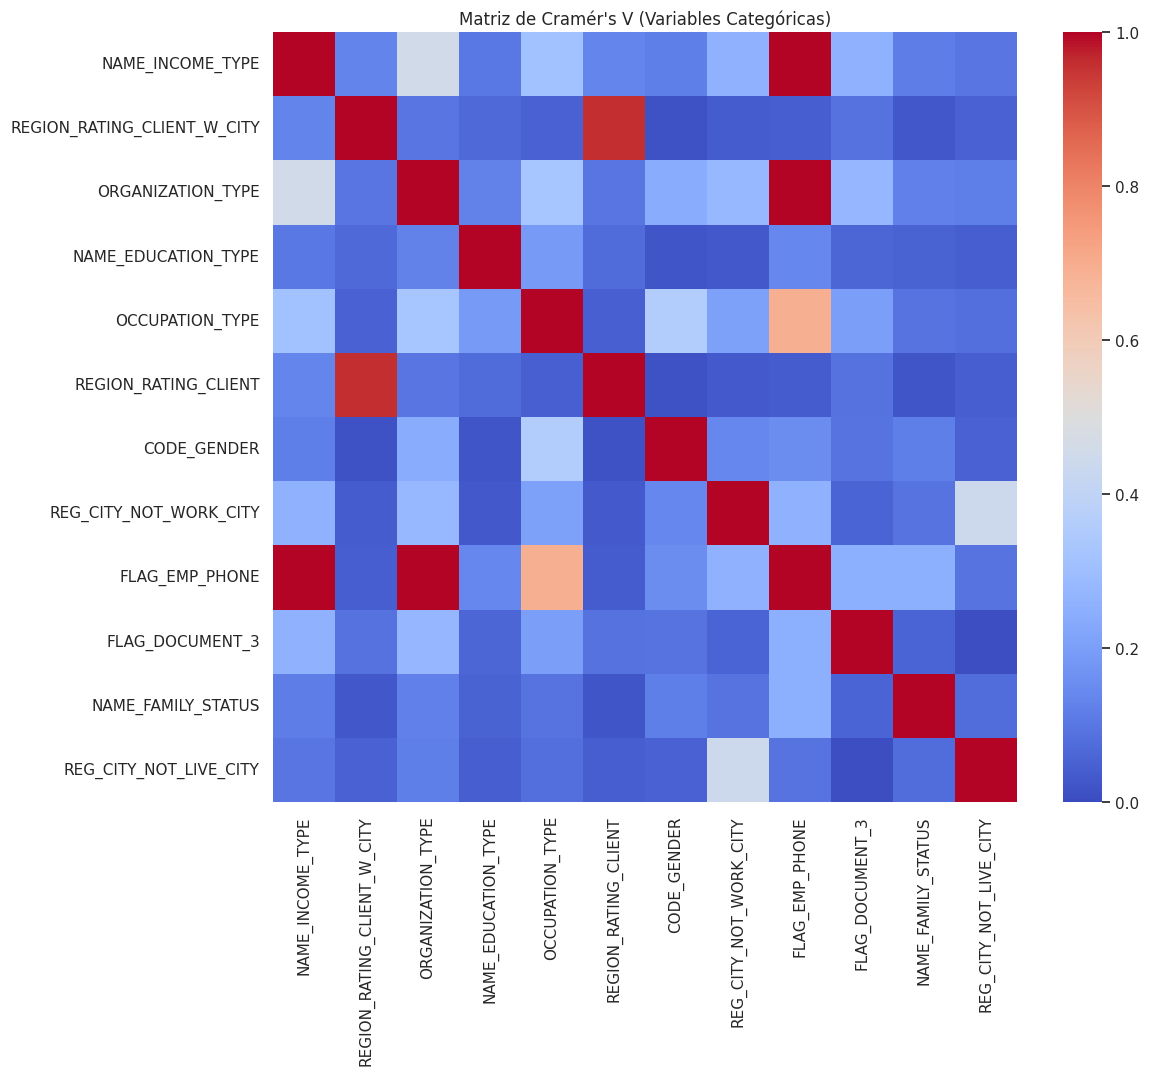

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(cramer_mat.astype(float), annot=False, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Matriz de Cramér's V (Variables Categóricas)")
plt.show()

In [ ]:
# ==============================================================================
# ELIMINACIÓN DE VARIABLES CATEGÓRICAS/DISCRETAS ALTAMENTE CORRELACIONADAS (Cramér's V)
# ==============================================================================

# Definimos el umbral de correlación de Cramér (85%)
umbral_cramer = 0.85

# Nos quedamos solo con el triángulo superior de la matriz de Cramér
# (Esto evita comparar A con B y B con A, permitiendo elegir solo una para borrar)
triangulo_superior_cramer = cramer_mat.where(np.triu(np.ones(cramer_mat.shape), k=1).astype(bool))

# Buscamos qué columnas superan el umbral en el triángulo superior
columnas_cramer_eliminadas = [
    columna for columna in triangulo_superior_cramer.columns
    if any(triangulo_superior_cramer[columna] > umbral_cramer)
]

print(f"Se han detectado {len(columnas_cramer_eliminadas)} variables categóricas/discretas con una asociación de Cramér mayor al {umbral_cramer*100}%.\n")
print(f"Variables redundantes a eliminar: {columnas_cramer_eliminadas}\n")

# Eliminamos estas variables redundantes en TODOS los conjuntos de datos
X_train = X_train.drop(columns=columnas_cramer_eliminadas, errors='ignore')
X_val = X_val.drop(columns=columnas_cramer_eliminadas, errors='ignore')
X_test = X_test.drop(columns=columnas_cramer_eliminadas, errors='ignore')

# Actualizamos la lista global de variables útiles para tus siguientes celdas
variables_utiles = [col for col in variables_utiles if col not in columnas_cramer_eliminadas]

print("==================================================")
print("DIMENSIONES TRAS EL FILTRO DE ASOCIACIÓN DE CRAMÉR")
print("==================================================")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Se han detectado 2 variables categóricas/discretas con una asociación de Cramér mayor al 85.0%.

Variables redundantes a eliminar: ['REGION_RATING_CLIENT', 'FLAG_EMP_PHONE']

DIMENSIONES TRAS EL FILTRO DE ASOCIACIÓN DE CRAMÉR
X_train: (182968, 22)
X_val:   (78416, 22)
X_test:  (46127, 22)


Vemos que hemos reducido bastante el número de características respecto al número original que teníamos de las mismas, que eran 122.

Ahora procedemos a visualizar algunos de nuestros datos para tener una idea de si se diferencian bien las dos categorías en alguna variable en concreto. Tomaremos una muestra balanceada en vez de estratificada porque queremos ver si hay distinción entre los datos. Si la hicieramos estratificada predominaría de sobremanera en el gráfico el color que representa a la clase de la gente que paga.

Visualizando muestra balanceada (2500 vs 2500) de las variables: ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'DAYS_EMPLOYED', 'DAYS_BIRTH', 'AMT_CREDIT', 'DAYS_LAST_PHONE_CHANGE', 'CANTIDAD_NULOS', 'REGION_POPULATION_RELATIVE', 'NULOS_INICIALES', 'DAYS_ID_PUBLISH', 'AMT_ANNUITY', 'DAYS_REGISTRATION']

Generando Scatter Matrix... (esto puede tardar un par de segundos)


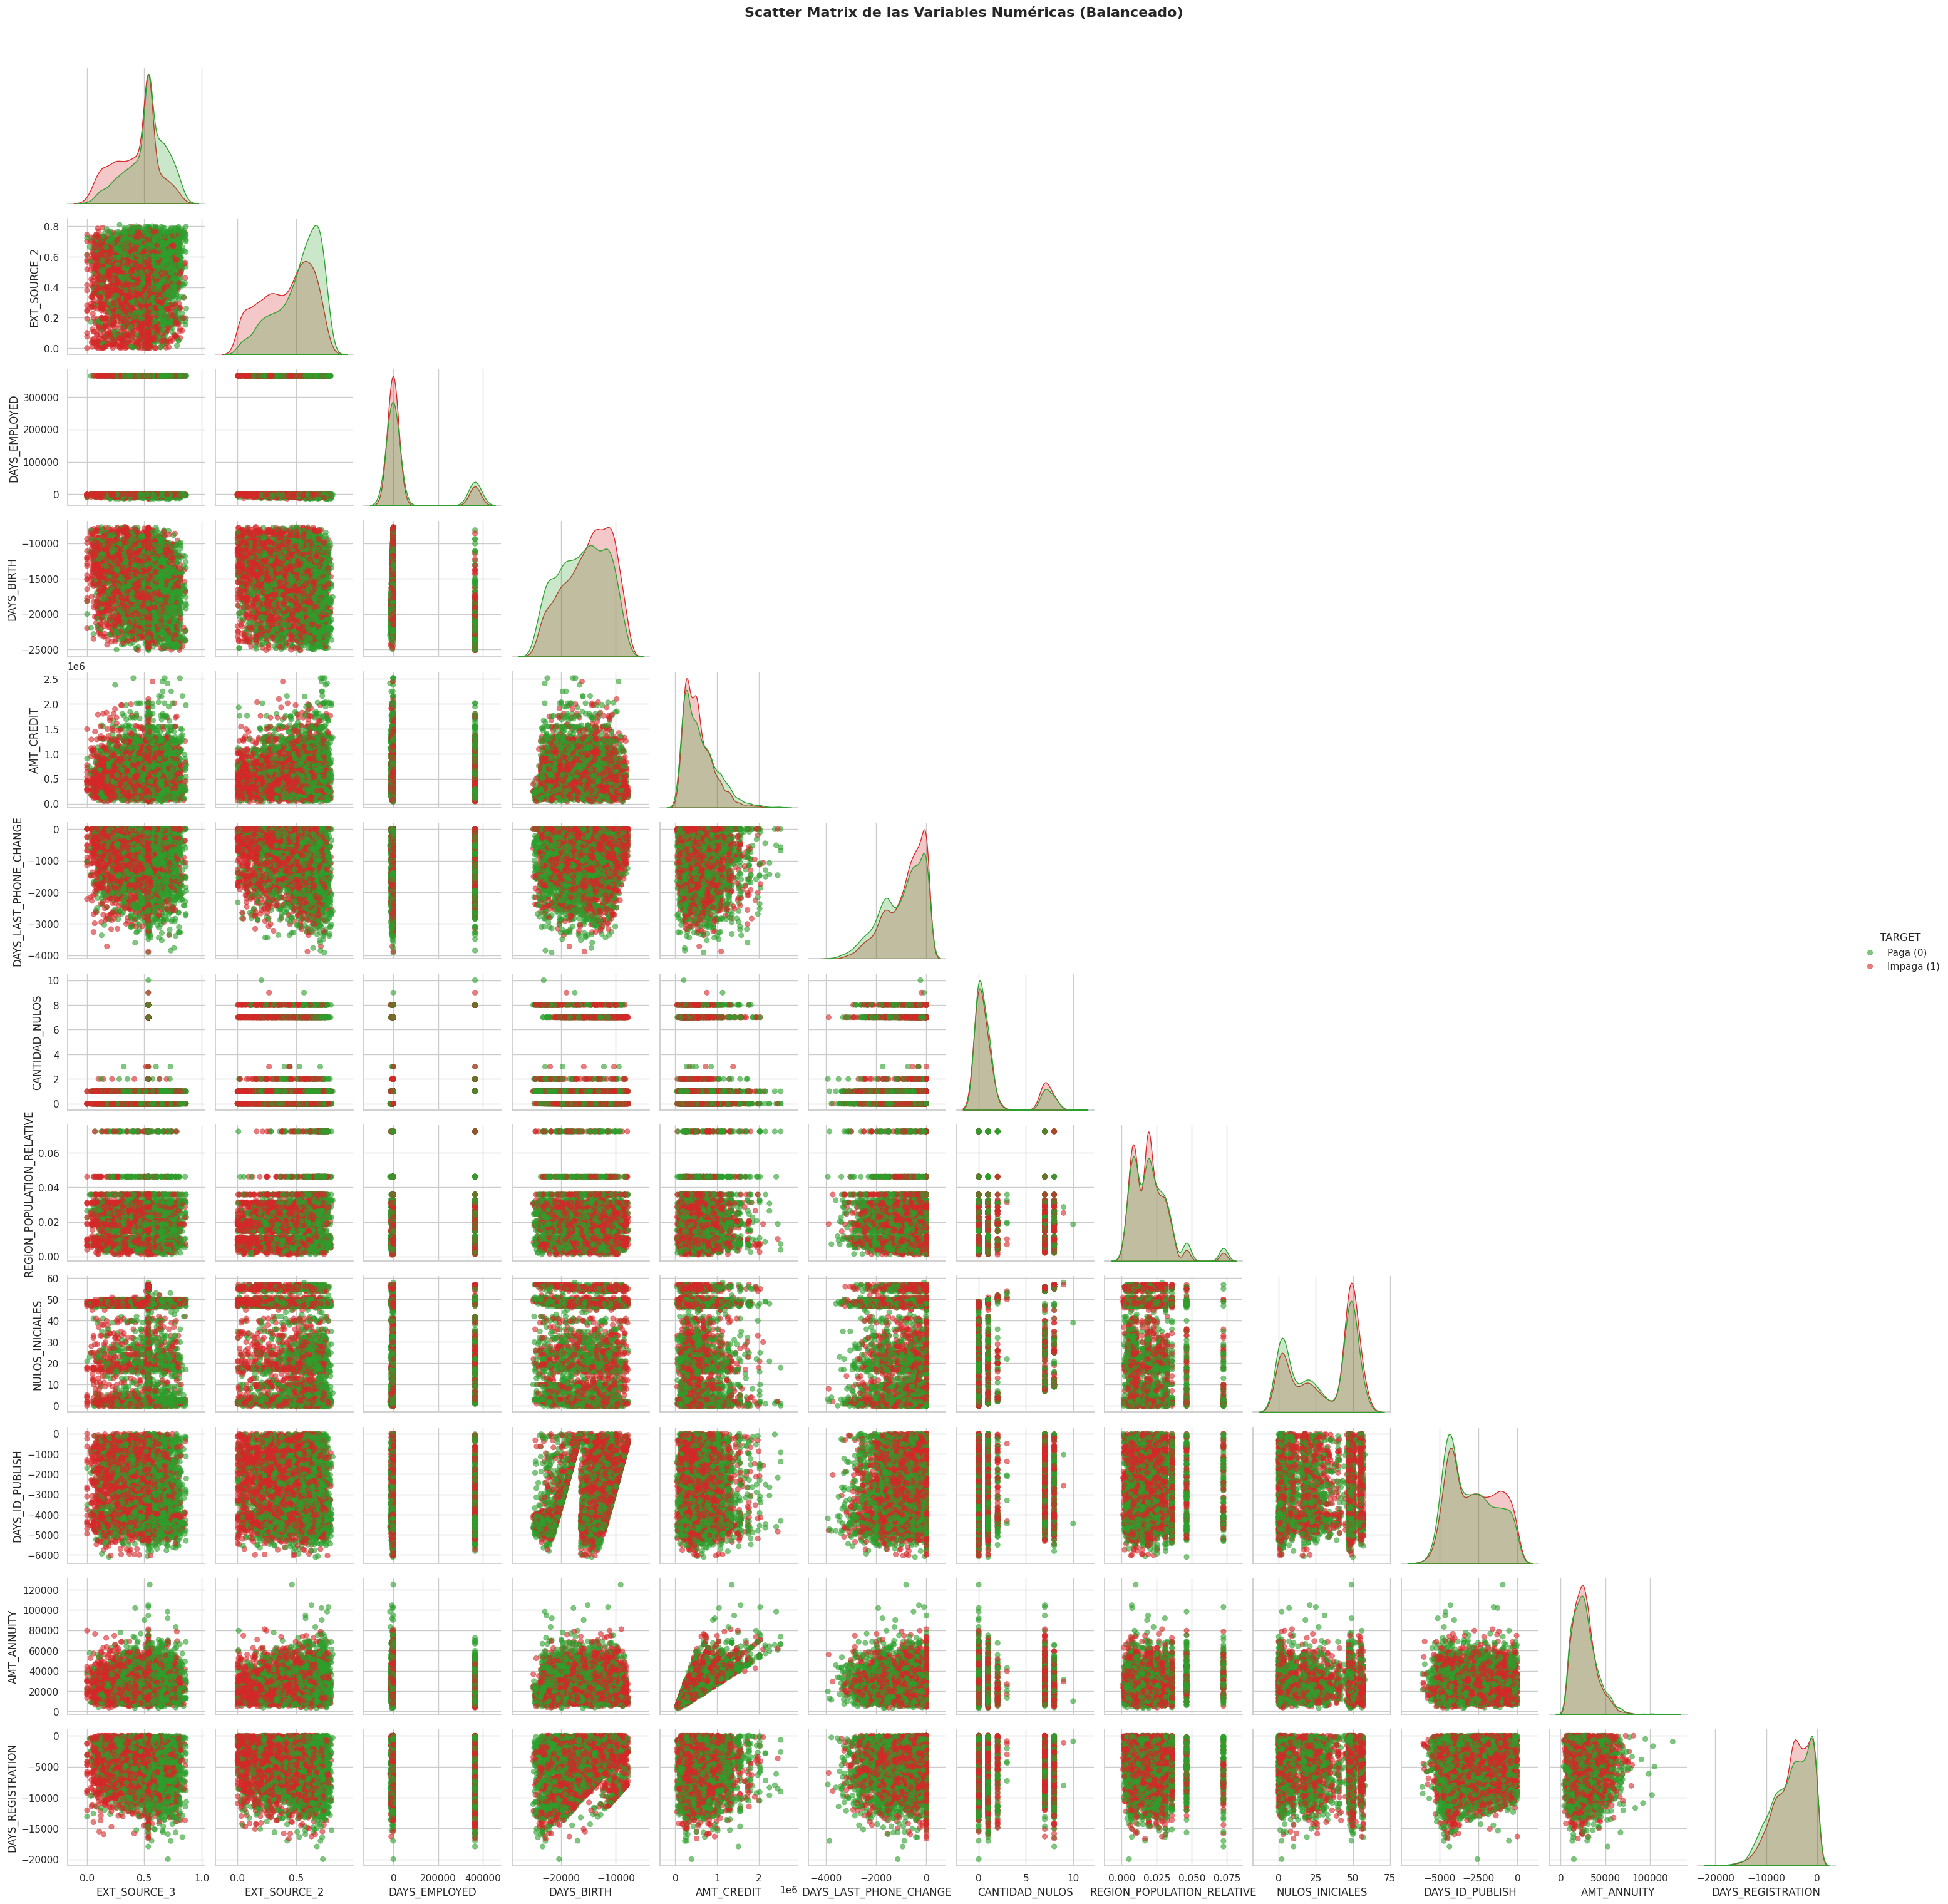

In [ ]:
# ==============================================================================
# VISUALIZACIÓN EXPLORATORIA (Muestra Balanceada)
# ==============================================================================

# PREPARACIÓN DE DATOS: MUESTRA BALANCEADA (50/50)
# Separamos los índices por clase
idx_paga = y_train[y_train == 0].index
idx_impaga = y_train[y_train == 1].index

# Cogemos 2500 de cada uno de forma aleatoria
n_muestras = 2500
idx_paga_sample = np.random.choice(idx_paga, n_muestras, replace=False)
idx_impaga_sample = np.random.choice(idx_impaga, n_muestras, replace=False)

# Unimos los índices y creamos los DataFrames de la muestra
indices_muestra = np.concatenate([idx_paga_sample, idx_impaga_sample])
muestra_X = X_train.loc[indices_muestra]
muestra_y = y_train.loc[indices_muestra]

# Preparamos el DataFrame para plotear
df_plot = muestra_X.copy()
df_plot['TARGET'] = muestra_y.replace({0: 'Paga (0)', 1: 'Impaga (1)'})

top_4_num = [i for i in variables_utiles if i in num_cont_final]
print(f"Visualizando muestra balanceada (2500 vs 2500) de las variables: {top_4_num}\n")

# SCATTER MATRIX (Pairplot)
print("Generando Scatter Matrix... (esto puede tardar un par de segundos)")
# Barajamos las filas aleatoriamente para evitar que un color tape al otro
df_plot = df_plot.sample(frac=1, random_state=42)
sns.pairplot(df_plot[top_4_num + ['TARGET']], hue='TARGET',
             palette={'Paga (0)': '#2ca02c', 'Impaga (1)': '#d62728'},
             diag_kind='kde', corner=True, plot_kws={'alpha': 0.6, 'edgecolor': None})

plt.suptitle('Scatter Matrix de las Variables Numéricas (Balanceado)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

Vemos que tampoco es que se pueda apreciar gran cosas en los gráficos.

Posteriormente normalizaremos ya que algunas variables como `DAYS_EMPLOYED`están muy sobre escaladas:

### Reducción de la dimensionalidad - PCA
Aunque hayamos reducido considerablemente el número de características estamos en la obligación de intentar tirar del cable todo lo que podamos. Vamos a probar a realizar **componentes principales** a ver si conseguimos reducir la dimensionalidad.

Recordamos que para este método solo podemos considerar variables numéricas así que partimos de 27 variables. También recordamos que como aquí lo que se busca es la máxima variabilidad, tenemos que poner todas las variables en la misma escala (si no se centraría en las que tiene mayor varianza).

Para ello vamos a ver si los datos tienen la misma magnitud o parecida o si necesitamos normalizar.


In [ ]:
# ==============================================================================
# JUSTIFICACIÓN DEL ESCALADO DE DATOS (Diferencia de Magnitudes)
# ==============================================================================
# Extraemos un resumen estadístico básico (media, desviación típica, min y max)
resumen_escalas = X_train.describe().loc[['mean', 'std', 'min', 'max']].T

# Le damos un poco de formato para que los números grandes se lean bien
pd.options.display.float_format = '{:,.2f}'.format

print(" ANÁLISIS DE MAGNITUDES PREVIO AL PCA:")
print("Observamos diferencias abismales en las escalas de las variables originales.\n")
resumen_escalas

 ANÁLISIS DE MAGNITUDES PREVIO AL PCA:
Observamos diferencias abismales en las escalas de las variables originales.



,mean,std,min,max
EXT_SOURCE_3,0.52,0.17,0.00,0.90
EXT_SOURCE_2,0.51,0.19,0.00,0.85
DAYS_EMPLOYED,"63,454.18","140,975.38","-17,546.00","365,243.00"
DAYS_BIRTH,"-16,032.61","4,362.26","-25,197.00","-7,673.00"
NAME_INCOME_TYPE,3.90,2.22,0.00,6.00
REGION_RATING_CLIENT_W_CITY,2.03,0.50,1.00,3.00
ORGANIZATION_TYPE,29.46,20.44,0.00,57.00
NAME_EDUCATION_TYPE,3.19,1.30,0.00,4.00
OCCUPATION_TYPE,7.18,4.45,0.00,18.00
AMT_CREDIT,"600,641.91","404,123.45","45,000.00","4,050,000.00"


Efectivamente necesitamos normalizar los datos, para ellos usaremos la función `StandardScaler` ya que así hacemos que la varianza de cada grupo sea 1 y sean la misma. Mejorando el resultado de las componentes principales.

In [ ]:
# Pequeño ajuste:
num_cols_final = [i for i in variables_utiles if i in num_cont_final]
cat_cols_final = [i for i in variables_utiles if i in num_disc_final+cat_final]
len(num_cols_final+cat_cols_final)

22

In [ ]:
# ==============================================================================
#  NORMALIZACIÓN Y COMPONENTES PRINCIPALES (PCA)
# ==============================================================================

print(f"Número de variables numéricas antes del PCA: {len(num_cols_final)}")

# ESTANDARIZACIÓN PURA (Requisito para PCA)

# Ajustamos SOLO en Train para evitar fuga de datos
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[num_cols_final])
X_val_num_scaled   = scaler.transform(X_val[num_cols_final])
X_test_num_scaled  = scaler.transform(X_test[num_cols_final])

# APLICACIÓN DEL PCA
# Le pedimos al PCA que retenga el 90% de la información (varianza explicada)
pca = PCA(n_components=0.90, random_state=42)

X_train_pca = pca.fit_transform(X_train_num_scaled)
X_val_pca   = pca.transform(X_val_num_scaled)
X_test_pca  = pca.transform(X_test_num_scaled)

componentes_usados = pca.n_components_
varianza_total = sum(pca.explained_variance_ratio_) * 100

print(f"El PCA ha comprimido las 12 variables en {componentes_usados} Componentes Principales.")
print(f"Estos componentes retienen el {varianza_total:.2f}% de la información original.\n")

# RECONSTRUCCIÓN DE LOS DATASETS (Numéricas PCA + Categóricas originales)
# Convertimos los arrays del PCA de vuelta a DataFrames para poder unirlos
df_train_pca = pd.DataFrame(X_train_pca, index=X_train.index,
                            columns=[f'PCA_Comp_{i}' for i in range(1, componentes_usados + 1)])
df_val_pca = pd.DataFrame(X_val_pca, index=X_val.index,
                          columns=[f'PCA_Comp_{i}' for i in range(1, componentes_usados + 1)])
df_test_pca = pd.DataFrame(X_test_pca, index=X_test.index,
                           columns=[f'PCA_Comp_{i}' for i in range(1, componentes_usados + 1)])

# Unimos las nuevas numéricas comprimidas con las categóricas que guardamos antes
X_train_final = pd.concat([df_train_pca, X_train[cat_cols_final]], axis=1)
X_val_final   = pd.concat([df_val_pca, X_val[cat_cols_final]], axis=1)
X_test_final  = pd.concat([df_test_pca, X_test[cat_cols_final]], axis=1)

print(f" Preprocesamiento Finalizado. El dataset listo para entrenar tiene {X_train_final.shape[1]} columnas en total.")

Número de variables numéricas antes del PCA: 12
El PCA ha comprimido las 12 variables en 10 Componentes Principales.
Estos componentes retienen el 95.23% de la información original.

 Preprocesamiento Finalizado. El dataset listo para entrenar tiene 20 columnas en total.


Aunque se ha ejecutado el Análisis de Componentes Principales (PCA) para cumplir con los requisitos metodológicos de compresión, se ha decidido **NO** utilizar los componentes generados para el modelado final.

**Justificación:**
El PCA requirió 10 componentes para retener el 90% de la varianza, reduciendo apenas 2 dimensiones respecto a las 12 variables originales filtradas. Sin embargo, el coste de usar PCA es perder el significado de las características reduciendo la interpretabilidad debido a que se usan combinaciones lineales de las mismas. Decidimos entonces que por 2 dimensiones es mejor no seguir con los resultados de esta técnica y quedarnos con las variables originales y su significado intacto.

Se descartan tambien otros métodos de reducción de dimensionalidad como la **proyección aleatoria** (que funciona bien cuando tenemos muchas muchas variables) y la **factorización no negativa de matrices** pues no todas las características toman valores puramente positivos.

## Entrenamiento y evaluación de modelos
Ya hemos hecho todo lo que podíamos hacer con el preprocesamiento de los datos, vamos a aprender el entrenamiento y la evaluación de modelos

### Clasificador trivial

Lo primero que haremos será un clasificador trivial (siempre predice la clase si que es la mayoritaria) para poder comparar luego con los modelos que realicemos.

In [ ]:
# ==============================================================================
# CLASIFICADOR TRIVIAL (Suelo de rendimiento)
# ==============================================================================
# El Dummy solo necesita conocer la clase mayoritaria en y_train
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

# Predicciones
y_pred_dummy = dummy.predict(X_val)
y_prob_dummy = dummy.predict_proba(X_val)[:, 1]

print(" CLASIFICADOR TRIVIAL (Nuestra línea base de referencia)")
print(f"Accuracy: {dummy.score(X_val, y_val):.4f}")
print(f"F1-Score (Morosos): {f1_score(y_val, y_pred_dummy):.4f}")
print(f"ROC AUC: {roc_auc_score(y_val, y_prob_dummy):.4f}")

print("\nReporte de Clasificación (¡El modelo trivial es inútil para detectar riesgo!):")
# zero_division=0 evita errores al intentar calcular métricas de una clase que nunca predice
print(classification_report(y_val, y_pred_dummy, target_names=['Paga (0)', 'Impaga (1)'], zero_division=0))

 CLASIFICADOR TRIVIAL (Nuestra línea base de referencia)
Accuracy: 0.9193
F1-Score (Morosos): 0.0000
ROC AUC: 0.5000

Reporte de Clasificación (¡El modelo trivial es inútil para detectar riesgo!):
              precision    recall  f1-score   support

    Paga (0)       0.92      1.00      0.96     72086
  Impaga (1)       0.00      0.00      0.00      6330

    accuracy                           0.92     78416
   macro avg       0.46      0.50      0.48     78416
weighted avg       0.85      0.92      0.88     78416



Vemos que el modelo cumple con lo que se esperaba de él (tiene muy buen *accuracy* pero porque las clases están desbalanceadas). Nos fijamos en el *macro avg* que es la media del métrica F1 score de las clases. Cualquier modelo que de verdad haya aprendido debería de dar mejores resultados que este.

### Regresión logística

Vamos a construir ahora un modelo algo más complejo, anuque simple dentro de lo que cabe. Vamos a hacer un modelo de regresión logística a ver que resultados obtenemos pues este tiene la ventaja de ser muy interpretable, nos puede servir también como *baseline* para comparar otros modelos.

Para la regresión logística como es un modelo lineal vamos a utilizar one hot encoding y vamos a aprovechar el normalizado que calculamos antes

Dataset Baseline listo con 22 columnas.

RESULTADOS DEL BASELINE EN VALIDACIÓN
--------------------------------------------------
ROC AUC Score: 0.7339
F1-Score (Morosos): 0.2493

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

    Paga (0)       0.96      0.67      0.79     72086
  Impaga (1)       0.15      0.67      0.25      6330

    accuracy                           0.67     78416
   macro avg       0.56      0.67      0.52     78416
weighted avg       0.89      0.67      0.75     78416



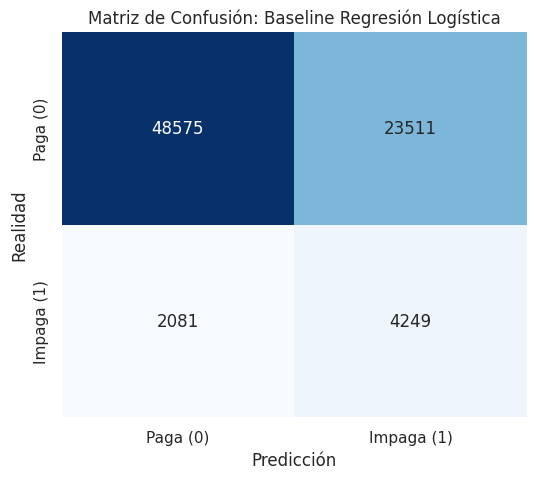

In [ ]:
# ==============================================================================
# PREPARACIÓN FINAL Y MODELO BASELINE (Regresión Logística)
# ==============================================================================

# One-Hot Encoding (Solo para el modelo lineal)
X_train_cat_ohe = pd.get_dummies(X_train[cat_cols_final], drop_first=True)
X_val_cat_ohe   = pd.get_dummies(X_val[cat_cols_final], drop_first=True)

# Alineamos para evitar desajustes de dimensiones
X_train_cat_ohe, X_val_cat_ohe = X_train_cat_ohe.align(X_val_cat_ohe, join='left', axis=1, fill_value=0)

# Construcción de los Datasets de Regresión Logística
# Juntamos las numéricas escaladas (StandardScaler) con las categóricas OHE
df_train_num = pd.DataFrame(X_train_num_scaled, index=X_train.index, columns=num_cols_final)
df_val_num   = pd.DataFrame(X_val_num_scaled, index=X_val.index, columns=num_cols_final)

X_train_lr = pd.concat([df_train_num, X_train_cat_ohe], axis=1)
X_val_lr   = pd.concat([df_val_num, X_val_cat_ohe], axis=1)

print(f"Dataset Baseline listo con {X_train_lr.shape[1]} columnas.\n")

# Entrenamiento del Modelo (Con balanceo de pesos)
# max_iter=1000 asegura que el algoritmo matemático converja sin dar warnings
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_lr.fit(X_train_lr, y_train)

# Predicciones en Validación
y_pred_val_lr = modelo_lr.predict(X_val_lr)
y_prob_val_lr = modelo_lr.predict_proba(X_val_lr)[:, 1] # Probabilidades para la curva ROC

# Evaluación
print("RESULTADOS DEL BASELINE EN VALIDACIÓN")
print("-" * 50)
print(f"ROC AUC Score: {roc_auc_score(y_val, y_prob_val_lr):.4f}")
print(f"F1-Score (Morosos): {f1_score(y_val, y_pred_val_lr):.4f}\n")

print("Reporte de Clasificación Detallado:")
print(classification_report(y_val, y_pred_val_lr, target_names=['Paga (0)', 'Impaga (1)']))


# ==============================================================================
# MATRIZ DE CONFUSIÓN
# ==============================================================================

cm = confusion_matrix(y_val, y_pred_val_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Paga (0)', 'Impaga (1)'],
            yticklabels=['Paga (0)', 'Impaga (1)'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión: Baseline Regresión Logística')
plt.show()

Como nos estamos fijando en el f1 macro, vemos que el modelo es algo mejor que el trivial, pero para nuestro gusto, deja bastante que desear todavía.

Vamos a intentar aprovechar la arquitectura logística al máximo intentando optimizar el parámetro C de regulación, mediante un algoritmo de búsqueda `GridSearch` en el que probaremos varios ordenes de magnitudes.

In [ ]:
# ==============================================================================
# OPTIMIZACIÓN DE LA REGRESIÓN LOGÍSITCA  (GridSearchCV)
# ==============================================================================

# Definimos el rango de valores para C (en escala logarítmica)
params = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(modelo_lr, params, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_lr, y_train)

print(f"Mejor C encontrado: {grid.best_params_['C']}")
print(f"Mejor F1-Score obtenido: {grid.best_score_:.4f}")

# Ahora usamos el mejor modelo para evaluar
modelo_final_lr = grid.best_estimator_
y_pred_final = modelo_final_lr.predict(X_val_lr)

Mejor C encontrado: 0.001
Mejor F1-Score obtenido: 0.2487


Vemos que el F1-Score obtenido **de la clase Impago** es prácticamente el mismo que teníamos antes. Quizás si hubieramos usado un `RobustScaler` en lugar del normalizado que hemos hecho habría salido mejor porque es más robusto a outliers, pero como se calcula de forma prácticamente idéntica y ya teníamos el estandarizado calculado decidimos usar ese, ya que usar el robusto no tiene ningún interés adicional y vamos a usar un modelo más potente igualmente.

### Gradient Boosting

Pasamos a usar un método "más pesado" que nos debería de dar mejores resultados. En este caso vamos a usar un método de *ensemble* como es Gradient Boosting. Recordamos que es un método en el que se concatenan varios árboles de forma consecutiva donde el siguiente arbol tiene como variable objetivo predecir el error del árbol anterior.

Este método cae fácil en el sobreajuste así que tenemos que mantener los árboles simples limitando su profundidad para que puedan generalizar.

Como trabajamos con árboles no necesitamos tratar de forma especial a las variables, es decir, nos da igual la magnitud de las numéricas y no necesitamos one-hot en las categóricas. De hecho, esto último incluso empeoraría el modelo

En concreto vamos a trabajar con la libería `LightGBM`

Como primera aproximación vamos a usar la configuración estándar


In [ ]:
# ==============================================================================
# LightGBM
# ==============================================================================


# Convertimos las columnas categóricas al tipo explícito 'category'
# Es vital convertir las categóricas a tipo 'category' para que LGBM las gestione bien

for col in cat_cols_final:
    X_train[col] = X_train[col].astype('category')
    X_val[col]   = X_val[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

print(" Datos convertidos. Listos para entrenar el LightGBM.")

# Entrenamiento
modelo_lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1
)

modelo_lgbm.fit(X_train, y_train)

# Evaluación
y_pred_lgbm = modelo_lgbm.predict(X_val)
y_prob_lgbm = modelo_lgbm.predict_proba(X_val)[:, 1]

print(" RESULTADOS LIGHTGBM (Tratamiento nativo de categóricas)")
print("-" * 50)
print(f"ROC AUC: {roc_auc_score(y_val, y_prob_lgbm):.4f}")
print(f"F1-Score (Morosos): {f1_score(y_val, y_pred_lgbm):.4f}")
print(classification_report(y_val, y_pred_lgbm, target_names=['Paga (0)', 'Impaga (1)']))

 Datos convertidos. Listos para entrenar el LightGBM.
[LightGBM] [Info] Number of positive: 14771, number of negative: 168197
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2512
[LightGBM] [Info] Number of data points in the train set: 182968, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432470
[LightGBM] [Info] Start training from score -2.432470
 RESULTADOS LIGHTGBM (Tratamiento nativo de categóricas)
--------------------------------------------------
ROC AUC: 0.7341
F1-Score (Morosos): 0.2696
              precision    recall  f1-score   support

    Paga (0)       0.95      0.77      0.85     72086
  Impaga (1)       0.18      0.57      0.27      6330

    accuracy                           0.75     78416
   macro avg     

In [ ]:
# ==============================================================================
# DIAGNÓSTICO DE RENDIMIENTO (Train vs Val)
# ==============================================================================

# Predicciones Train
y_pred_train = modelo_lgbm.predict(X_train)
y_prob_train = modelo_lgbm.predict_proba(X_train)[:, 1]

# Predicciones Val
y_pred_val = modelo_lgbm.predict(X_val)
y_prob_val = modelo_lgbm.predict_proba(X_val)[:, 1]

print("\n" + "="*50)
print(" COMPARATIVA DE SOBREAJUSTE (Train vs Validación)")
print("="*50)

print(f"ROC AUC    | TRAIN: {roc_auc_score(y_train, y_prob_train):.4f}  -->  VAL: {roc_auc_score(y_val, y_prob_val):.4f}")
print(f"F1-Score   | TRAIN: {f1_score(y_train, y_pred_train):.4f}  -->  VAL: {f1_score(y_val, y_pred_val):.4f}")


print("\n--- REPORTE DETALLADO EN VALIDACIÓN ---")
print(classification_report(y_val, y_pred_val, target_names=['Paga (0)', 'Impaga (1)']))


 COMPARATIVA DE SOBREAJUSTE (Train vs Validación)
ROC AUC    | TRAIN: 0.9078  -->  VAL: 0.7341
F1-Score   | TRAIN: 0.4072  -->  VAL: 0.2696

--- REPORTE DETALLADO EN VALIDACIÓN ---
              precision    recall  f1-score   support

    Paga (0)       0.95      0.77      0.85     72086
  Impaga (1)       0.18      0.57      0.27      6330

    accuracy                           0.75     78416
   macro avg       0.56      0.67      0.56     78416
weighted avg       0.89      0.75      0.80     78416



Vemos que el modelo está bastante sobreajustado, así que intentamos reducir ese sobreajuste. Para ello vamos a usar **EarlyStopping** y pesos personalizados que calculamos explicitamente además de búscar el mejor umbral (el que maximiza el F1 score)

In [ ]:
# Calculamos el multiplicador exacto (Cuántos buenos hay por cada moroso)
peso_morosos =y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Peso aplicado a la clase minoritaria: {peso_morosos:.2f}")

# Entrenamos el modelo obligándole a usar ese peso
modelo_lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    scale_pos_weight=peso_morosos,
    random_state=42,
    n_jobs=-1
)

modelo_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Predicciones puras en Validación
y_prob_val = modelo_lgbm.predict_proba(X_val)[:, 1]

# BUSCAMOS DEL UMBRAL PERFECTO
# Calculamos todas las opciones posibles
precision, recall, thresholds = precision_recall_curve(y_val, y_prob_val)

# Calculamos el F1-Score para cada umbral posible
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) # 1e-10 evita dividir por cero
mejor_indice = np.argmax(f1_scores)
umbral_perfecto = thresholds[mejor_indice]

print("\n" + "="*50)
print(f"UMBRAL ÓPTIMO ENCONTRADO: {umbral_perfecto:.4f}")
print("="*50)

# Aplicamos ese umbral exacto
y_pred_definitiva = (y_prob_val >= umbral_perfecto).astype(int)

print(classification_report(y_val, y_pred_definitiva, target_names=['Paga (0)', 'Impaga (1)']))
print(f"ROC AUC Final: {roc_auc_score(y_val, y_prob_val):.4f}")
print(f"F1-Score (Morosos): {f1_score(y_val, y_pred_definitiva):.4f}")

Peso aplicado a la clase minoritaria: 11.39
[LightGBM] [Info] Number of positive: 14771, number of negative: 168197
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2512
[LightGBM] [Info] Number of data points in the train set: 182968, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432470
[LightGBM] [Info] Start training from score -2.432470

UMBRAL ÓPTIMO ENCONTRADO: 0.1135
              precision    recall  f1-score   support

    Paga (0)       0.95      0.83      0.88     72086
  Impaga (1)       0.19      0.45      0.27      6330

    accuracy                           0.80     78416
   macro avg       0.57      0.64      0.58     78416
weighted avg       0.88      0.80      0.83     78416

ROC AUC Final: 0.7110
F1-Score (Mor

In [ ]:
# ==============================================================================
# DIAGNÓSTICO DE RENDIMIENTO (Train vs Val)
# ==============================================================================

# Predicciones Train
y_pred_train = modelo_lgbm.predict(X_train)
y_prob_train = modelo_lgbm.predict_proba(X_train)[:, 1]
y_pred_train_definitiva = (y_prob_train >= umbral_perfecto).astype(int)

# Predicciones Val
y_pred_val_definitiva=y_pred_definitiva
y_pred_val = modelo_lgbm.predict(X_val)

print("\n" + "="*50)
print(" COMPARATIVA DE SOBREAJUSTE (Train vs Validación)")
print("="*50)

print(f"ROC AUC    | TRAIN: {roc_auc_score(y_train, y_prob_train):.4f}  -->  VAL: {roc_auc_score(y_val, y_prob_val):.4f}")
print(f"F1-Score   | TRAIN: {f1_score(y_train, y_pred_train_definitiva):.4f}  -->  VAL: {f1_score(y_val, y_pred_val_definitiva):.4f}")


print("\n--- REPORTE DETALLADO EN VALIDACIÓN ---")
print(classification_report(y_val, y_pred_val_definitiva, target_names=['Paga (0)', 'Impaga (1)']))


 COMPARATIVA DE SOBREAJUSTE (Train vs Validación)
ROC AUC    | TRAIN: 0.7161  -->  VAL: 0.7110
F1-Score   | TRAIN: 0.2658  -->  VAL: 0.2665

--- REPORTE DETALLADO EN VALIDACIÓN ---
              precision    recall  f1-score   support

    Paga (0)       0.95      0.83      0.88     72086
  Impaga (1)       0.19      0.45      0.27      6330

    accuracy                           0.80     78416
   macro avg       0.57      0.64      0.58     78416
weighted avg       0.88      0.80      0.83     78416



Vemos que efectivamente este ya no está sobreajustado

Como este modelo ya no está sobreajustado nos vamos a quedar con él y además vamos a intentar optimizar hiperparámetros

#### Optimización con Optuna

Ahora vamos a explorar la librería `Optuna` que usa optimización bayesiana y vamos a intentar optimizar el modelo de Gradient Boosting

In [ ]:
# ==============================================================================
# OPTIMIZACIÓN PROFESIONAL CON OPTUNA
# ==============================================================================


def objective(trial):
    # Definimos el espacio de búsqueda
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    }

    # Entrenamos con el split de validación
    gbm = lgb.LGBMClassifier(**param, scale_pos_weight=peso_morosos, n_estimators=500)
    gbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Evaluamos con F1-Score
    preds = gbm.predict(X_val)
    score = f1_score(y_val, preds)
    return score

# Lanzamos la optimización
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # Probamos 30 combinaciones inteligentes

print(f"Mejor score: {study.best_value}")
print(f"Mejores parámetros: {study.best_params}")

[I 2026-06-15 08:57:54,456] A new study created in memory with name: no-name-7524043e-8731-4762-9930-b2f28b6c4ff5
[I 2026-06-15 08:58:02,884] Trial 0 finished with value: 0.25814490639435933 and parameters: {'lambda_l1': 1.0589737131778287e-07, 'lambda_l2': 1.822313857269164, 'num_leaves': 30, 'feature_fraction': 0.9191560920442529, 'bagging_fraction': 0.5187416689872898, 'bagging_freq': 4, 'min_child_samples': 40, 'learning_rate': 0.07524646842441522}. Best is trial 0 with value: 0.25814490639435933.
[I 2026-06-15 08:58:16,341] Trial 1 finished with value: 0.27394650054965186 and parameters: {'lambda_l1': 0.6172219986970294, 'lambda_l2': 1.2305561945137958e-06, 'num_leaves': 219, 'feature_fraction': 0.46139269451532805, 'bagging_fraction': 0.836824873999213, 'bagging_freq': 5, 'min_child_samples': 50, 'learning_rate': 0.05119663752139227}. Best is trial 1 with value: 0.27394650054965186.
[I 2026-06-15 08:58:21,979] Trial 2 finished with value: 0.2500075759871511 and parameters: {'lamb

Mejor score: 0.2795306185887473
Mejores parámetros: {'lambda_l1': 8.644208516478793, 'lambda_l2': 7.782891400418142e-07, 'num_leaves': 256, 'feature_fraction': 0.5483425876286606, 'bagging_fraction': 0.838129237672246, 'bagging_freq': 6, 'min_child_samples': 51, 'learning_rate': 0.013554351808108591}


### Evaluación del modelo final e importancia de las características

Con el modelo ya optimizado vamos a ver qué resultados devuelve para el conjunto de validación

 RESULTADOS FINALES DEL MODELO OPTIMIZADO
--------------------------------------------------
ROC AUC Final: 0.7084
F1-Score (Morosos): 0.0000

Reporte de Clasificación Final:
              precision    recall  f1-score   support

    Paga (0)       0.92      1.00      0.96     72086
  Impaga (1)       0.00      0.00      0.00      6330

    accuracy                           0.92     78416
   macro avg       0.46      0.50      0.48     78416
weighted avg       0.85      0.92      0.88     78416



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


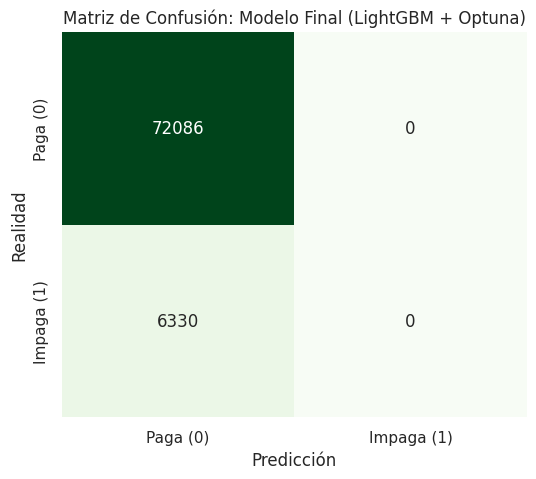

In [ ]:
# ==============================================================================
# EVALUACIÓN FINAL DEL MODELO OPTIMIZADO
# ==============================================================================

# Obtenemos el modelo con los mejores parámetros encontrados por Optuna
best_params = study.best_params
modelo_final_lgbm = lgb.LGBMClassifier(**best_params, scale_pos_weight=peso_morosos, random_state=42)
modelo_final_lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

# Predicciones finales
y_pred_final = modelo_final_lgbm.predict(X_val)
y_prob_final = modelo_final_lgbm.predict_proba(X_val)[:, 1]

# Métricas clave
print(" RESULTADOS FINALES DEL MODELO OPTIMIZADO")
print("-" * 50)
print(f"ROC AUC Final: {roc_auc_score(y_val, y_prob_final):.4f}")
print(f"F1-Score (Morosos): {f1_score(y_val, y_pred_final):.4f}")

# Reporte detallado
print("\nReporte de Clasificación Final:")
print(classification_report(y_val, y_pred_final, target_names=['Paga (0)', 'Impaga (1)']))

# Matriz de Confusión para ver si hemos reducido los falsos positivos
cm = confusion_matrix(y_val, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Paga (0)', 'Impaga (1)'],
            yticklabels=['Paga (0)', 'Impaga (1)'])
plt.title('Matriz de Confusión: Modelo Final (LightGBM + Optuna)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

Vemos que el modelo es el clasificador trivial, esto se debe a que no hemos seleccionado un umbral todavía como hicimos antes y ha usado el umbral por defecto. Buscaremos ahora el mejor umbral

#### Importancia de las variables

Como el modelo está formado por árboles no podemos no imprimir la importancia de las variables que es un método integrado (es gratis!)

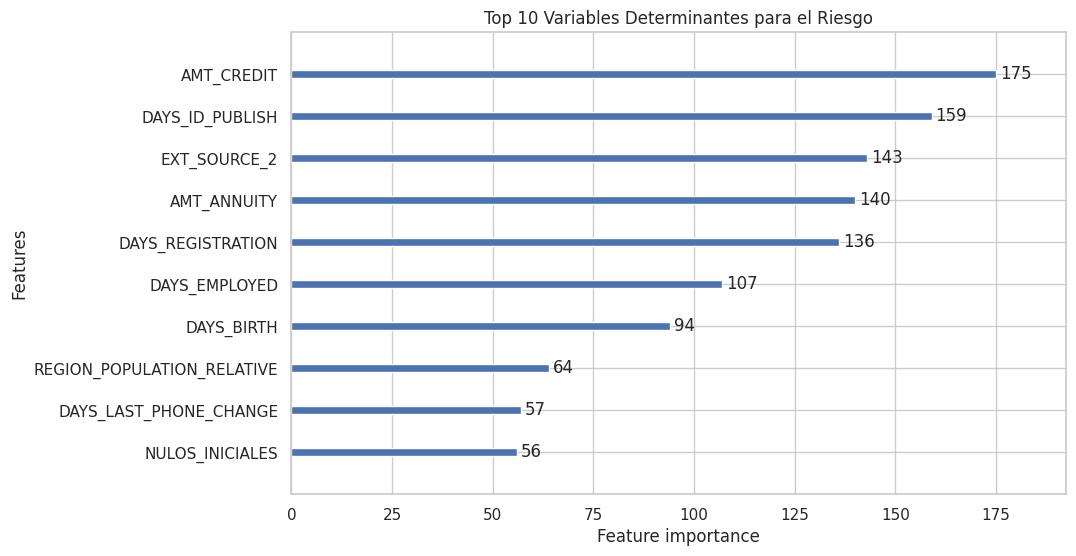

In [ ]:
lgb.plot_importance(modelo_final_lgbm, max_num_features=10, figsize=(10, 6))
plt.title("Top 10 Variables Determinantes para el Riesgo")
plt.show()

Vemos que la  variable **AMT_CREDIT** es la que más imporatancia tiene, las importancias parecen equilibradas

Como ya hemos dicho antes, lo único que podemos hacer para mejorar  el modelo es búscar el umbral óptimo de selección (tenemos ya el modelo optimizado por optuna) pues ahora mismo por defecto tenemos el clasificador trivial. Vamos a buscar el umbral óptimo con el conjunto de validación que de esto no se encarga optuna. Pintamos la curva PR

#### Selección de Umbral

Como tras la optimización de Optuna tenemos un nuevo modelo, vamos a buscar también el umbral más óptimo

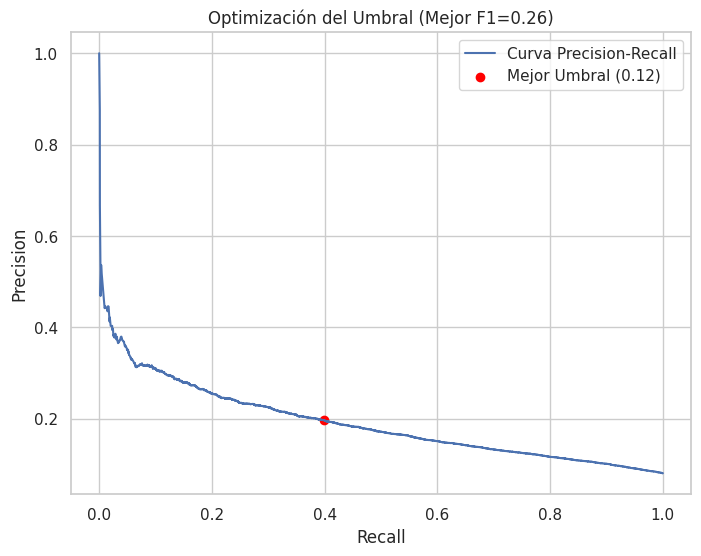

El umbral óptimo que maximiza el F1-Score es: 0.1159


In [ ]:
# ==============================================================================
# ANÁLISIS DE UMBRAL Y CURVA PRECISION-RECALL
# ==============================================================================

# Calculamos precision y recall para todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_final)

# Calculamos F1 para cada punto de la curva
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# Pintamos la curva
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='Curva Precision-Recall')
plt.scatter(recalls[best_idx], precisions[best_idx], marker='o', color='red',
            label=f'Mejor Umbral ({best_threshold:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Optimización del Umbral (Mejor F1={f1_scores[best_idx]:.2f})')
plt.legend()
plt.show()

print(f"El umbral óptimo que maximiza el F1-Score es: {best_threshold:.4f}")

Ajustamos el nuevo umbral en validación y volvemos a calcular las métricas y la matriz de confusión

 VALIDACIÓN CON UMBRAL OPTIMIZADO (0.1159)
------------------------------------------------------------
              precision    recall  f1-score   support

    Paga (0)     0.9420    0.8575    0.8978     72086
  Impaga (1)     0.1972    0.3987    0.2639      6330

    accuracy                         0.8205     78416
   macro avg     0.5696    0.6281    0.5809     78416
weighted avg     0.8819    0.8205    0.8466     78416



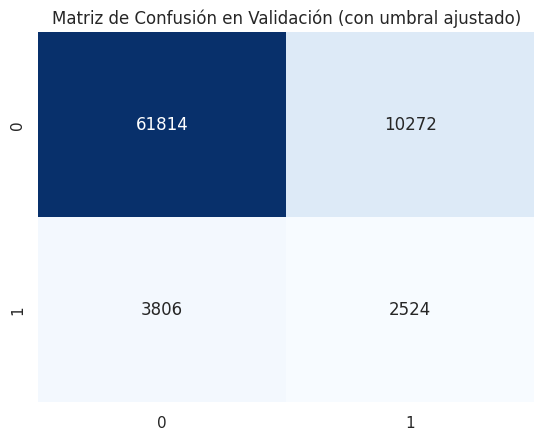

In [ ]:
# ==============================================================================
# EVALUACIÓN Y AJUSTE EN VALIDACIÓN
# ==============================================================================

# Aplicamos el mejor umbral encontrado con la curva PR a los datos de validación
y_pred_val_ajustado = (y_prob_final >= best_threshold).astype(int)

print(f" VALIDACIÓN CON UMBRAL OPTIMIZADO ({best_threshold:.4f})")
print("-" * 60)
print(classification_report(y_val, y_pred_val_ajustado,
                            target_names=['Paga (0)', 'Impaga (1)'],
                            digits=4))

# Visualización rápida de la mejora
cm_val = confusion_matrix(y_val, y_pred_val_ajustado)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión en Validación (con umbral ajustado)')
plt.show()

Vemos que ya no estamos ante el clasificador trivial al haber movido el umbral, aunque realmente para la selección de este umbral se requeriría la ayuda de un experto en la materia. Esto se debe a que mientras nosotros solo nos estamos centrando en obtener un buen resultado, quizás un experto nos dice que prefiere que seamos rígidos ante los impagos pues prefiere tener muchos falsos negativos a que se le escapen falsos positivos y tener más morosos aunque con las métricas sea un "peor resultado".

#### Resultados en el conjunto Test

 RESULTADOS FINALES EN TEST (Utilizando umbral: 0.1159)
------------------------------------------------------------
              precision    recall  f1-score   support

    Paga (0)     0.9420    0.8606    0.8995     42403
  Impaga (1)     0.2001    0.3972    0.2662      3724

    accuracy                         0.8232     46127
   macro avg     0.5711    0.6289    0.5828     46127
weighted avg     0.8821    0.8232    0.8484     46127



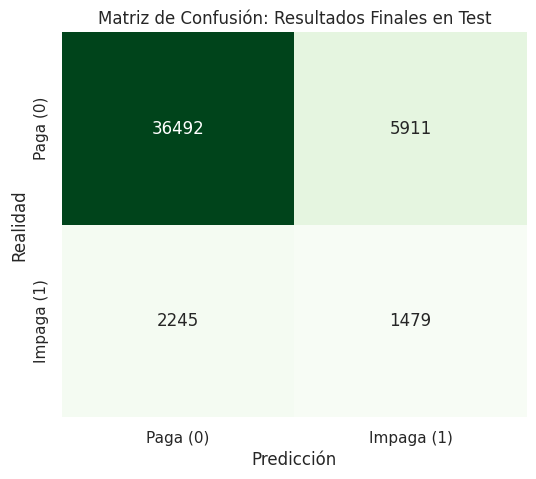

In [ ]:

# ==============================================================================
# RESULTADOS FINALES EN TEST
# ==============================================================================

# Aplicamos el umbral fijo de validación al conjunto de Test
y_pred_test = modelo_final_lgbm.predict(X_test)
y_prob_test = modelo_final_lgbm.predict_proba(X_test)[:, 1]
y_pred_test_final = (y_prob_test >= best_threshold).astype(int)

print(f" RESULTADOS FINALES EN TEST (Utilizando umbral: {best_threshold:.4f})")
print("-" * 60)
print(classification_report(y_test, y_pred_test_final,
                            target_names=['Paga (0)', 'Impaga (1)'],
                            digits=4))

# Matriz de confusión definitiva
cm_test_final = confusion_matrix(y_test, y_pred_test_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test_final, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Paga (0)', 'Impaga (1)'],
            yticklabels=['Paga (0)', 'Impaga (1)'])
plt.title('Matriz de Confusión: Resultados Finales en Test')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

Vemos que realmente no se ha obtenido un mal resultado, pero tampoco uno maravilloso, el funcionamiento del modelo deja algo que desear pero supera con diferencia al clasificador trivial.

#### Último modelo: Entrenamiento con train+val

Como ya tenemos los hiperparámetros del modelo optimizado, vamos a probar a unificar de nuevo los datos de entrenamiento y validación y usar estos para construir un nuevo modelo. Igual ahora al tener más datos, el modelo es más eficaz

Como ahora no tenemos conjunto de validación para hacer *Earlystopping* vamos a recuperar el número de árboles del modelo anterior y usar los mismos

In [ ]:
numero_arboles = modelo_final_lgbm.best_iteration_

 RESULTADOS DEFINITIVOS (Tras reentrenamiento con Train+Val)
------------------------------------------------------------
              precision    recall  f1-score   support

    Paga (0)     0.9422    0.8605    0.8995     42403
  Impaga (1)     0.2008    0.3993    0.2673      3724

    accuracy                         0.8232     46127
   macro avg     0.5715    0.6299    0.5834     46127
weighted avg     0.8824    0.8232    0.8484     46127



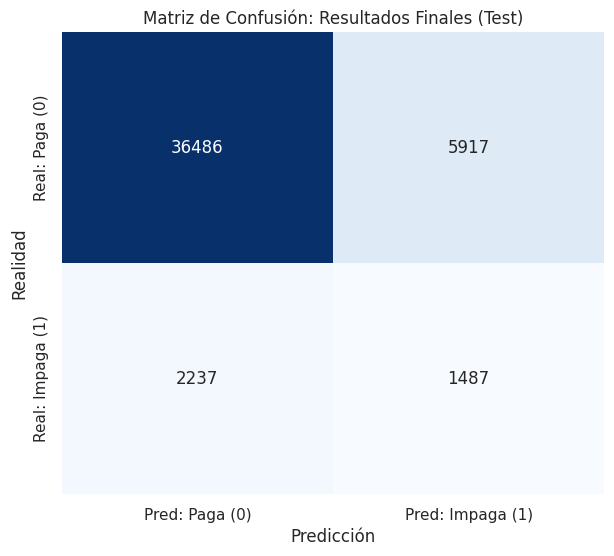

In [ ]:
# ==============================================================================
# REENTRENAMIENTO SOBRE TRAIN+VAL Y EVALUACIÓN EN TEST
# ==============================================================================

# Unimos Train y Val
X_final_train = pd.concat([X_train, X_val], axis=0)
y_final_train = pd.concat([y_train, y_val], axis=0)

# Aseguramos que las columnas categóricas sean del tipo 'category'
for col in cat_cols_final:
    X_final_train[col] = X_final_train[col].astype('category')



#  Reentrenamos el modelo con los mejores parámetros de Optuna
# (best_params es el diccionario que obtuvismos de study.best_params)
modelo_final_definitivo = lgb.LGBMClassifier(**study.best_params,scale_pos_weight=peso_morosos,
                                             n_estimators=numero_arboles ,random_state=42)
modelo_final_definitivo.fit(X_final_train, y_final_train)

# Evaluamos en el Test Set (fijado desde el principio)
y_prob_test_definitivo = modelo_final_definitivo.predict_proba(X_test)[:, 1]
y_pred_test_definitivo = (y_prob_test_definitivo >= best_threshold).astype(int)

# Imprimimos el veredicto final
print(" RESULTADOS DEFINITIVOS (Tras reentrenamiento con Train+Val)")
print("-" * 60)
print(classification_report(y_test, y_pred_test_definitivo, target_names=['Paga (0)', 'Impaga (1)'], digits=4))

# Generamos la matriz
cm_final = confusion_matrix(y_test, y_pred_test_definitivo)

# La visualizamos
plt.figure(figsize=(7, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Paga (0)', 'Pred: Impaga (1)'],
            yticklabels=['Real: Paga (0)', 'Real: Impaga (1)'])
plt.title('Matriz de Confusión: Resultados Finales (Test)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

Vemos que los resultados son prácticamente idénticos a los que teníamos de antes. Esto nos da como conclusión que con el conjunto de entrenamiento inicial ya había suficientes datos, más datos no han mejorado el modelo

#### Importancia de las variables en este último modelo

Para calcularlas ahora, vamos a usar el método de permutación. Por ver otro método diferente al método integrado de árboles


Calculando Permutation Feature Importance en el conjunto de Test...
Esto puede demorar unos minutos ya que el modelo se reevalúa barajando cada columna...

 Top 10 Variables por Permutación (Métrica: roc_auc):
-----------------------------------------------------------------
              Variable  Importancia_Media  Desviacion_Estandar
          EXT_SOURCE_2               0.09                 0.00
          EXT_SOURCE_3               0.02                 0.00
         DAYS_EMPLOYED               0.01                 0.00
            DAYS_BIRTH               0.01                 0.00
            AMT_CREDIT               0.01                 0.00
     ORGANIZATION_TYPE               0.01                 0.00
   NAME_EDUCATION_TYPE               0.00                 0.00
           CODE_GENDER               0.00                 0.00
           AMT_ANNUITY               0.00                 0.00
DAYS_LAST_PHONE_CHANGE               0.00                 0.00


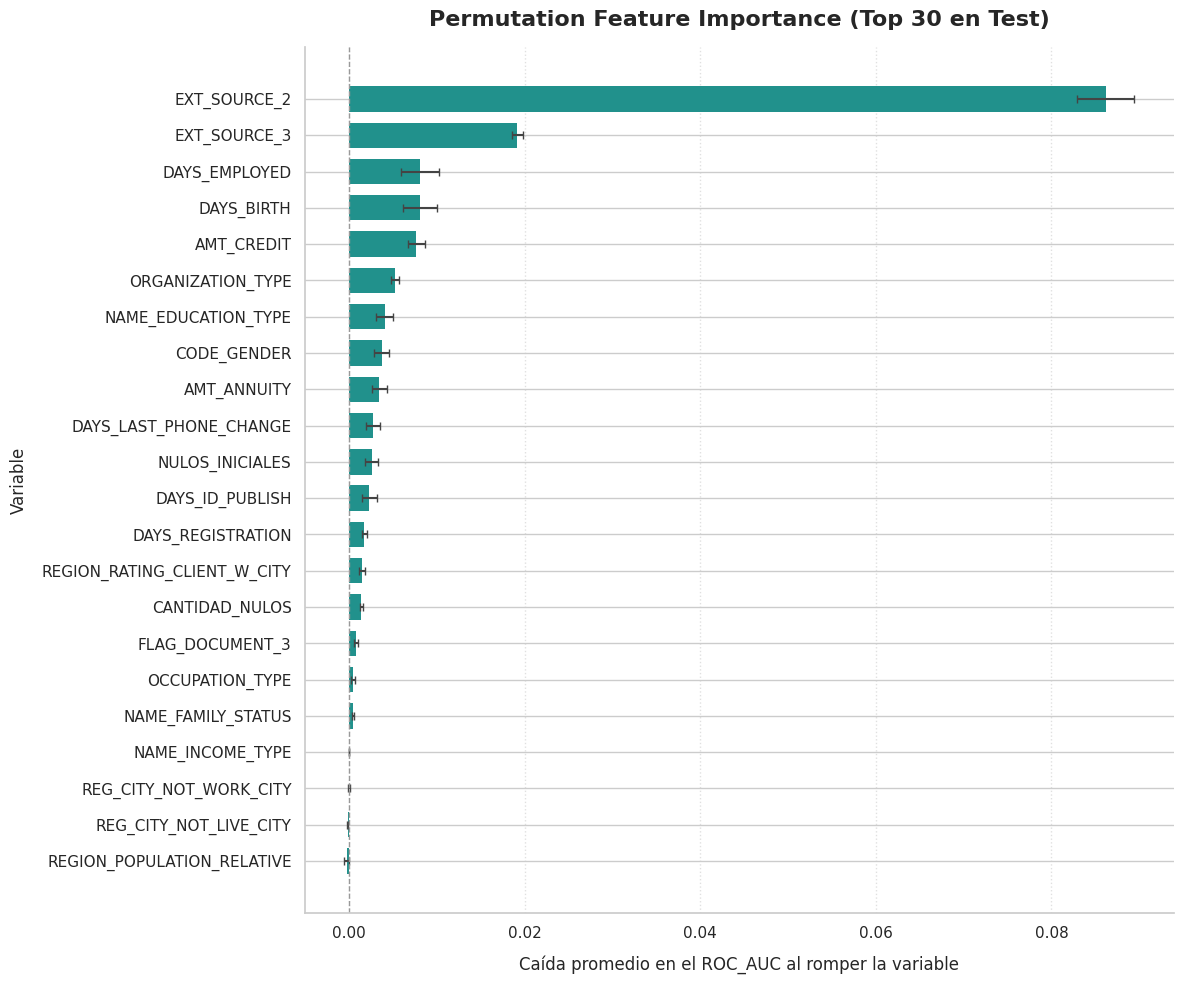

In [ ]:
# ==============================================================================
# IMPORTANCIA DE VARIABLES POR PERMUTACIÓN (Sobre el conjunto de Test)
# ==============================================================================
print("\nCalculando Permutation Feature Importance en el conjunto de Test...")
print("Esto puede demorar unos minutos ya que el modelo se reevalúa barajando cada columna...")

# Aseguramos que el tipo 'category' se mantenga también en X_test para evitar errores en LightGBM
X_test_perm = X_test.copy()
for col in cat_cols_final:
    if col in X_test_perm.columns:
        X_test_perm[col] = X_test_perm[col].astype('category')

# Usamos la métrica 'roc_auc' por el fuerte desbalanceo
metrica_evaluacion = 'roc_auc'

# Calculamos la importancia por permutación
resultado_perm = permutation_importance(
    modelo_final_definitivo,
    X_test_perm,
    y_test,
    scoring=metrica_evaluacion,
    n_repeats=5,           # Número de veces que se baraja cada variable
    random_state=42,
    n_jobs=-1              # Paralelismo total
)

# Estructuramos los resultados en un DataFrame y ordenamos de MENOR a MAYOR
# (Matplotlib pinta de abajo hacia arriba en gráficos de barras horizontales,
# por lo que para que la más importante salga arriba, el DataFrame debe estar invertido)
df_perm_importance = pd.DataFrame({
    'Variable': X_test_perm.columns,
    'Importancia_Media': resultado_perm.importances_mean,
    'Desviacion_Estandar': resultado_perm.importances_std
}).sort_values(by='Importancia_Media', ascending=True)

# Mostramos el Top 10 por consola (en orden descendente para que sea legible en texto)
print(f"\n Top 10 Variables por Permutación (Métrica: {metrica_evaluacion}):")
print("-" * 65)
print(df_perm_importance.sort_values(by='Importancia_Media', ascending=False).head(10).to_string(index=False))

# ==============================================================================
# GRÁFICO DE BARRAS HORIZONTALES CON MATPLOTLIB PURO
# ==============================================================================
# Nos quedamos con las últimas 'top_k' (las de mayor valor tras haber ordenado ascendentemente)
top_k_grafico = 30
df_grafico = df_perm_importance.tail(top_k_grafico)

fig, ax = plt.subplots(figsize=(12, 10))

# Dibujamos las barras horizontales incluyendo la barra de error (xerr)
barras = ax.barh(
    df_grafico['Variable'],
    df_grafico['Importancia_Media'],
    xerr=df_grafico['Desviacion_Estandar'],
    color='#21918c',      # Un color verde/azulado corporativo limpio
    edgecolor='none',
    height=0.7,
    error_kw={'ecolor': '#444444', 'lw': 1.5, 'capsize': 3} # Estilo de las barras de error
)

# Configuración de estética y etiquetas
ax.set_title(f'Permutation Feature Importance (Top {top_k_grafico} en Test)', fontsize=16, pad=15, weight='bold')
ax.set_xlabel(f'Caída promedio en el {metrica_evaluacion.upper()} al romper la variable', fontsize=12, labelpad=10)
ax.set_ylabel('Variable', fontsize=12, labelpad=10)

# Añadimos una línea vertical en el 0 para ver claramente si alguna variable da rendimiento negativo
ax.axvline(x=0, color='#999999', linestyle='--', linewidth=1)

# Limpieza de recuadros (spines) innecesarios para un look moderno
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Cuadrícula sutil solo en el eje X
ax.xaxis.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Vemos que aquí la variable más importante es **EXT_SOURCE_2**, que ocupaba el tercer lugar en la gráfica de la importancia de las variables del método integrado por árboles.

### Reflexiones analíticas y conclusiones

En esta sección se detallan los hallazgos y el impacto del proceso secuencial de ingeniería de características (*feature engineering*) y reducción de dimensionalidad aplicado sobre el conjunto de datos de entrenamiento masivo. El objetivo principal ha sido maximizar la densidad de información y eliminar el ruido estadístico antes del modelado definitivo.



#### Filtrado inicial de NA's
Ante la cantidad de variables que superaban el 50% de NA's se decidió establecer un **umbral de corte del 45%** para la eliminación directa de estas columnas.

* **Justificación:** Imputar más de la mitad de las instancias de una característica habría introducido un sesgo artificial masivo, pues más de la mitad de las instancias serían artificiales

* **Captura de Comportamiento:** Previo a la eliminación, se creó la variable `NULOS_INICIALES` para guardar el "patrón de omisión" del cliente como un potencial indicador de riesgo crediticio. Pues quizás la falata de información también es información.


#### Tratamiento de la Redundancia en Variables Continuas
Para las características estrictamente continuas (filtradas  al exigir más de 5 valores únicos para diferenciarlas de indicadores binarios o categóricos a pesar de ser todas de tipo numérico), se calculó la **matriz de correlación de Pearson** en valor absoluto.

* Con un  **umbral del 85% ($0.85$)**, se detectaron y eliminaron de forma segura las variables redundantes (como `AMT_GOODS_PRICE`, `CNT_FAM_MEMBERS`, `OBS_60_CNT_SOCIAL_CIRCLE` y `DEF_60_CNT_SOCIAL_CIRCLE`).
* Esto estabilizó el espacio muestral numérico, previniendo problemas de colinealidad en estimadores lineales y reduciendo el coste computacional.



#### Imputación, Codificación y Consistencia del Pipeline
A fin de eliminar la posibilidad de que ocurriera  fuga de datos (*data leakage*), se separó el dataset en conjunto de entrenamiento validación y prueba:
* **Variables Continuas:** Imputadas mediante la **mediana** para neutralizar el impacto de los valores atípicos (*outliers*)

* **Variables Discretas y Categóricas:** Imputadas de forma constante bajo las etiquetas especiales `-1` y `"Desconocido"`, respectivamente, preservando la naturaleza de la ausencia de información en lugar de asumir distribuciones sesgadas. Las categóricas textuales fueron transformadas mediante `OrdinalEncoder`.



### Selección de características por Filtros y Estadística (ANOVA y Chi-Cuadrado)
Para purgar las variables irrelevantes respecto a la variable objetivo (`TARGET`), se aplicaron pruebas de significancia estadística con un **umbral crítico de $p\text{-valor} < 0.1$**:
* **ANOVA (Test F):** Evaluó la separación de medias de las variables continuas entre clientes pagadores e impagadores.
* **Chi-Cuadrado de Contingencia ($\chi^2$):** Aplicado individualmente sobre las variables numéricas discretas, binarias y categóricas. Aquellas columnas que eran independientes de la variable objetivo (p-valor alto) se descartaron por ser incapaces de discriminar el impago.

*  **Información Mutua**: También realizamos la información mutua para la eliminación de las variables (si no gano información de la variable objetivo al conocer una variable esa variable es inútil).





### Análisis Estadístico No Lineal mediante V de Cramér
Para las variables categóricas y discretas supervivientes, se implementó una matriz de asociación basada en la **V de Cramér**. A diferencia de Pearson, este estadístico mide la fuerza de la asociación simétrica no lineal en un rango acotado entre $0$ y $1$.

* Al evaluar el triángulo superior con un **umbral del 85% ($0.85$)**, el algoritmo eliminó de manera controlada aquellas categorías redundantes que aportaban la misma información estructural que otras ya presentes en el dataset.



### Evaluación de Importancia por Permutación (*Permutation Importance*)
Tras optimizar los hiperparámetros del clasificador definitivo (`LGBMClassifier`) mediante optimización bayesiana (*Optuna*) y reentrenar sobre el conjunto combinado (*Train + Val*) se computó la **Permutación de Características** directamente sobre el conjunto de *Test* final, barajando aleatoriamente cada columna de manera independiente en 5 repeticiones (`n_repeats=5`) bajo la métrica **ROC-AUC**.

* **Veredicto Visual:** El gráfico resultante (Top 30) revela de forma transparente qué variables destruyen verdaderamente el poder de generalización del modelo al ser corrompidas. Variables como las fuentes externas (`EXT_SOURCE_2`) dan el mejor resultado en importancia, mientras que con el modelo sin unificar tenía el puesto número 3 al realizar la importancia por el método integrado. Esto se debe seguramente a la estocasticidad de los métodos de entrenamiento, aunque llama la atención que en ambos casos tenga un buen resultado. Se puede intuir que la variable es verdaderamente importante.


### Resultados obtenidos

Aunque rondamos el 60% de F1 score, el resultado no nos parece del todo satisfactorio pero es lo máximo a lo que hemos podido llegar. Seguramente esto se deba a la complejidad de la tarea, el desbalance de datos y que solo hemos usado un archivo de los múltiples que tenía el concurso de Kaggle. Reiteramos la importancia de hablar con expertos para por ejemplo, establecer un umbral o que nos dé ideas intuitivas sobre la importancia de las variables por ejemplo.

Por otro lado, tras compararlo con los otros modelos que hemos realizado (clasificador trivial) y regresión logística podemos decir que ha obtenido mejores resultados.